# Predicción de Peso al Nacer — EPS PUJ

## Resumen

La EPS PUJ necesita anticipar **qué bebés nacerán con bajo peso (< 5.5 lb / 2 500 g)** para aprovisionar con tiempo los cuidados neonatales especializados, que son costosos y limitados. Este notebook documenta el flujo analítico completo (CRISP-DM) sobre la base de **4 255 156 nacimientos** del año 2022, desde la limpieza de datos hasta la comparación de **7 modelos predictivos** sobre la variable objetivo `weight_pounds` (regresión).

**Estructura del notebook**

1. **Carga de datos** — lectura del CSV con los nacimientos.
2. **Calidad de datos** — análisis de nulos y exclusión de variables con *leakage* o no disponibles al momento de predecir.
3. **Análisis exploratorio orientado al negocio** — distribución del peso, identificación de factores predictivos clave.
4. **Ingeniería de características** — indicadores de reporte, variables de riesgo clínico y manejo de outliers.
5. **Modelado predictivo** — 7 modelos (lineales, ensambles de árboles, SVM y red neuronal).
6. **Resultados comparativos** — métricas en test (MAPE y % dentro de ±10 %).

**Métrica de negocio.** Reportamos MAPE (error porcentual absoluto medio) y el % de predicciones dentro de ±10 % del peso real. Esta segunda métrica responde directamente a la pregunta operativa: *¿con qué frecuencia el modelo me permite estimar el peso del bebé con un error tolerable para decidir el nivel de cuidado?*


In [1]:
from pathlib import Path

from IPython.display import display
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
sns.set_theme(style="whitegrid")
RNG = 42
np.random.seed(RNG)

## 1. Carga de datos

Se carga el CSV con los 4 255 156 nacimientos reportados por la EPS para 2022 y se inspeccionan las primeras filas para confirmar el esquema.


In [2]:
DATA_PATH = Path("peso_bebes.csv")

df = pd.read_csv(DATA_PATH)

# Mapeo de códigos de raza según el diccionario de datos del caso
RACE_MAP = {
    1: "White",
    2: "Negro",
    3: "Indio americano",
    4: "Chino",
    5: "Japonés",
    6: "Hawaiian",
    7: "Filipino",
    9: "Desconocido/OTRO",
    18: "Indio Asiático",
    28: "Coreano",
    39: "Samoan",
    48: "Vietnamita",
    99: np.nan
}

def mapear_raza(s):
    """Convierte códigos a etiqueta, manda los no mapeados a 'Desconocido/OTRO'
    y preserva los NaN originales (para que el análisis de nulos siga siendo fiel)."""
    mapped = s.map(RACE_MAP)
    codigo_no_mapeado = s.notna() & mapped.isna()
    mapped.loc[codigo_no_mapeado] = "Desconocido/OTRO"
    return mapped.astype("category")

for col in ["child_race", "mother_race", "father_race"]:
    if col in df.columns:
        df[col] = mapear_raza(df[col])

print("Dimensiones:", df.shape)
df.head(10)

Dimensiones: (4255156, 31)


,source_year,year,month,day,wday,state,is_male,child_race,weight_pounds,plurality,apgar_1min,apgar_5min,mother_residence_state,mother_race,mother_age,gestation_weeks,lmp,mother_married,mother_birth_state,cigarette_use,cigarettes_per_day,alcohol_use,drinks_per_week,weight_gain_pounds,born_alive_alive,born_alive_dead,born_dead,ever_born,father_race,father_age,record_weight
0,2022,2022,4,NaN,5,NaN,False,NaN,6.4375,1,NaN,9.0000,NaN,NaN,34,38.0000,7282007,True,NaN,NaN,NaN,NaN,NaN,30.0000,NaN,NaN,NaN,8.0000,NaN,49,1
1,2022,2022,3,NaN,5,NaN,False,NaN,7.2620,1,NaN,9.0000,NaN,NaN,38,40.0000,6102007,True,NaN,NaN,NaN,NaN,NaN,99.0000,NaN,NaN,NaN,8.0000,NaN,45,1
2,2022,2022,12,NaN,2,NaN,True,NaN,6.0010,1,NaN,9.0000,NaN,NaN,30,36.0000,4202008,False,NaN,NaN,NaN,NaN,NaN,54.0000,NaN,NaN,NaN,8.0000,NaN,38,1
3,2022,2022,10,NaN,4,NaN,True,NaN,8.1262,1,NaN,9.0000,NaN,NaN,31,38.0000,2052008,False,NaN,NaN,NaN,NaN,NaN,30.0000,NaN,NaN,NaN,8.0000,NaN,39,1
4,2022,2022,11,NaN,4,NaN,False,NaN,7.3127,1,NaN,9.0000,NaN,NaN,39,39.0000,2082008,True,NaN,NaN,NaN,NaN,NaN,10.0000,NaN,NaN,NaN,8.0000,NaN,40,1
5,2022,2022,10,NaN,5,NaN,False,NaN,5.7430,1,NaN,9.0000,NaN,NaN,34,33.0000,9082008,False,NaN,NaN,NaN,NaN,NaN,38.0000,NaN,NaN,NaN,8.0000,NaN,40,1
6,2022,2022,7,NaN,4,NaN,True,NaN,9.4997,1,NaN,9.0000,NaN,NaN,41,40.0000,9252007,True,NaN,False,NaN,False,NaN,22.0000,NaN,NaN,NaN,8.0000,NaN,44,1
7,2022,2022,9,NaN,7,NaN,False,NaN,6.2501,1,NaN,9.0000,NaN,NaN,31,37.0000,12172007,True,NaN,NaN,NaN,NaN,NaN,20.0000,NaN,NaN,NaN,8.0000,NaN,37,1
8,2022,2022,5,NaN,3,NaN,True,NaN,6.8123,1,NaN,9.0000,NaN,NaN,28,36.0000,9122007,True,NaN,NaN,NaN,NaN,NaN,25.0000,NaN,NaN,NaN,8.0000,NaN,30,1
9,2022,2022,7,NaN,5,NaN,False,NaN,4.2505,2,NaN,9.0000,NaN,NaN,35,37.0000,10302007,True,NaN,NaN,NaN,NaN,NaN,50.0000,NaN,NaN,NaN,8.0000,NaN,35,1


In [3]:
df.dtypes

source_year                  int64
year                         int64
month                        int64
day                        float64
wday                         int64
state                      float64
is_male                       bool
child_race                category
weight_pounds              float64
plurality                    int64
apgar_1min                 float64
apgar_5min                 float64
mother_residence_state     float64
mother_race               category
mother_age                   int64
gestation_weeks            float64
lmp                          int64
mother_married                bool
mother_birth_state         float64
cigarette_use               object
cigarettes_per_day         float64
alcohol_use                 object
drinks_per_week            float64
weight_gain_pounds         float64
born_alive_alive           float64
born_alive_dead            float64
born_dead                  float64
ever_born                  float64
father_race         

## 2. Calidad de datos

Antes de modelar se realizan tres tareas críticas:

1. **Normalizar `lmp`** (fecha del último período menstrual) a formato fecha para detectar valores inválidos.
2. **Cuantificar nulos** por columna.
3. **Excluir variables** que no estarán disponibles al momento de la predicción o que generan *leakage* (p. ej. apgar, que se mide después del parto).


In [4]:
lmp_str = df['lmp'].astype(str).str.zfill(8)
lmp_parsed = pd.to_datetime(lmp_str, format='%m%d%Y', errors='coerce')

df['lmp'] = lmp_parsed
print(f"Valores de fecha inválidos en lmp convertidos a nulo: {df['lmp'].isna().sum():,}")

Valores de fecha inválidos en lmp convertidos a nulo: 432,845


### 2.1 Nulos por columna

El siguiente resumen identifica columnas con datos faltantes. Hay tres patrones distintos:

- **100 % nulos** (`day`, `state`, `child_race`, `apgar_1min`, etc.): la EPS no captura estos campos; deben excluirse.
- **~65-68 % nulos** (`cigarette_use`, `alcohol_use`, `mother_race`): faltante de datos — refleja diferencias de reporte por estado, no ausencia del fenómeno. Imputar a 'No fuma' inventaría señal.
- **< 3 % nulos** (`weight_gain_pounds`, `ever_born`, `gestation_weeks`, `weight_pounds`): faltantes manejables con imputación.


In [5]:
null_counts = df.isnull().sum()
null_pct = (df.isnull().mean() * 100).round(2)

null_summary = pd.DataFrame({
    "nulos": null_counts,
    "porcentaje_nulos": null_pct.round(2)
}).sort_values("porcentaje_nulos", ascending=False)

# Mostrar solo columnas que tienen al menos un nulo
null_summary_filtered = null_summary[null_summary["nulos"] > 0]
print(f"Columnas con valores nulos: {len(null_summary_filtered)} de {len(df.columns)}")
print(f"Total de registros: {len(df):,}\n")
display(null_summary_filtered)

Columnas con valores nulos: 21 de 31
Total de registros: 4,255,156



,nulos,porcentaje_nulos
mother_birth_state,4255156,100.0000
day,4255156,100.0000
state,4255156,100.0000
born_alive_alive,4255156,100.0000
child_race,4255156,100.0000
born_alive_dead,4255156,100.0000
born_dead,4255156,100.0000
apgar_1min,4255156,100.0000
drinks_per_week,4255156,100.0000
mother_residence_state,4255156,100.0000


### 2.2 Variables excluidas

Se excluyen las variables que:

- Se miden **después del nacimiento** (`apgar_1min`, `apgar_5min`) → causarían fuga de información.
- Son **constantes o no aportan** (`source_year`, `year`, `month`, `day`, `wday`, `state`).
- Son metadatos administrativos (`record_weight`).
- Tienen 100 % de nulos (`child_race`, `mother_residence_state`, `born_alive_*`, `born_dead`).
- Son redundantes con `gestation_weeks` (`lmp`).


In [6]:
DROP_LEAKAGE = [
    "apgar_1min",
    "apgar_5min",
    "source_year",
    "year",
    "month",
    "day",
    "wday",
    "state",
    "child_race",
    "mother_residence_state",
    "mother_birth_state",
    "born_alive_alive",
    "born_alive_dead",
    "born_dead",
    "lmp",
    "record_weight",
    "drinks_per_week"
]

drop_present = [c for c in DROP_LEAKAGE if c in df.columns]
df_base = df.drop(columns=drop_present, errors="ignore").copy()
print("Eliminadas:", drop_present)
print("Columnas restantes:", list(df_base.columns))

Eliminadas: ['apgar_1min', 'apgar_5min', 'source_year', 'year', 'month', 'day', 'wday', 'state', 'child_race', 'mother_residence_state', 'mother_birth_state', 'born_alive_alive', 'born_alive_dead', 'born_dead', 'lmp', 'record_weight', 'drinks_per_week']
Columnas restantes: ['is_male', 'weight_pounds', 'plurality', 'mother_race', 'mother_age', 'gestation_weeks', 'mother_married', 'cigarette_use', 'cigarettes_per_day', 'alcohol_use', 'weight_gain_pounds', 'ever_born', 'father_race', 'father_age']


In [7]:
df_base.dtypes

is_male                   bool
weight_pounds          float64
plurality                int64
mother_race           category
mother_age               int64
gestation_weeks        float64
mother_married            bool
cigarette_use           object
cigarettes_per_day     float64
alcohol_use             object
weight_gain_pounds     float64
ever_born              float64
father_race           category
father_age               int64
dtype: object

### 2.3 Variable objetivo y filas válidas

La variable objetivo es **`weight_pounds`**. Las filas sin peso registrado no son útiles ni para entrenar ni para evaluar, por lo que decidimos que se eliminan, además solo corresponden a ~0.1 % de los registros.


In [8]:
df_base = df_base.dropna(subset=["weight_pounds"])

## 3. Análisis exploratorio


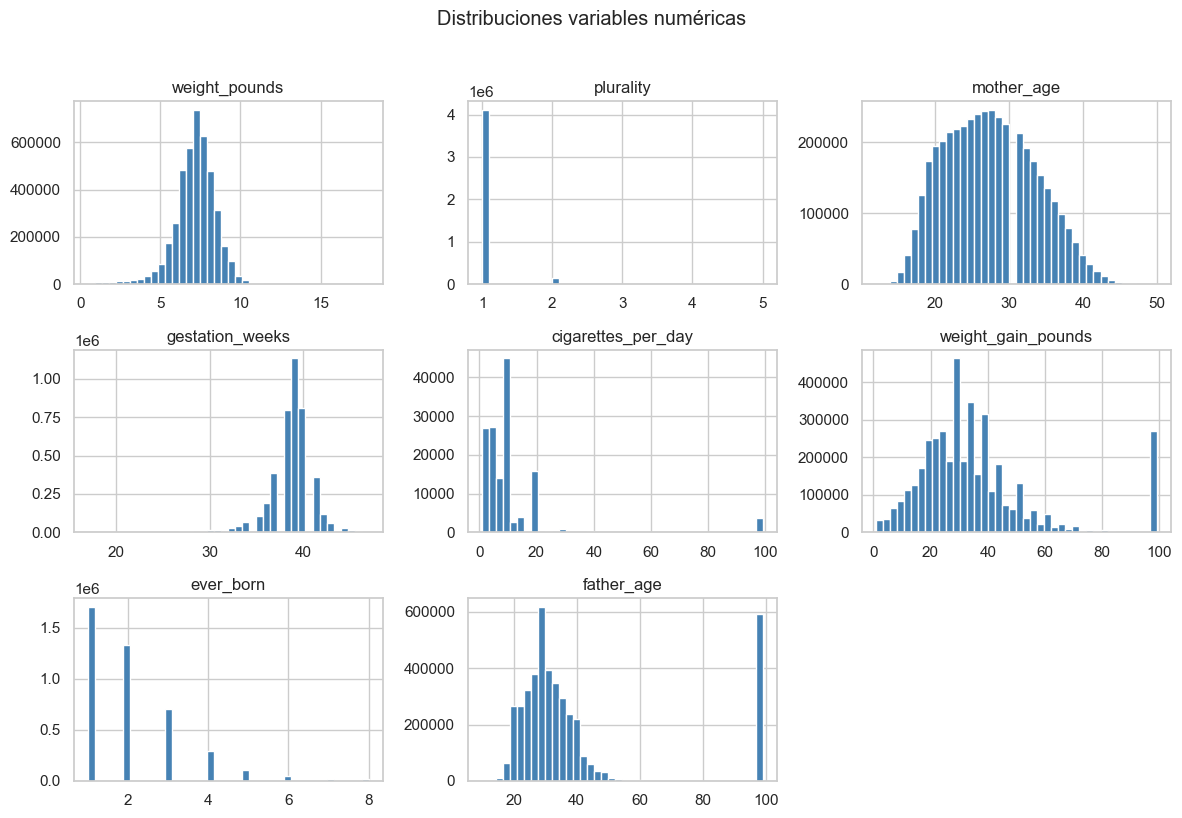

In [9]:
numeric_plot = df_base.select_dtypes(include=['number']).columns.tolist()
df_base[numeric_plot].hist(bins=40, figsize=(12, 8), color="steelblue", edgecolor="white")
plt.suptitle("Distribuciones variables numéricas", y=1.02)
plt.tight_layout()
plt.show()

Con el histograma se observa que las variables `weight_gain_pounds` y `father_age` tienen valores atípicos registrados como 99, se va a proceder a poner estos datos dummie como nulos.

In [10]:
df_base['weight_gain_pounds'] = df_base['weight_gain_pounds'].replace(99, np.nan)
df_base['father_age'] = df_base['weight_gain_pounds'].replace(99, np.nan)

### 3.1 Faltantes restantes tras la limpieza

Después de excluir las variables no usables, revisamos los faltantes que quedan en las features candidatas.

Observamos tres grupos de datos distintos, el primero `cigarettes_per_day` con 97% nulos, el segundo tabaco/alcohol/raza con ~65% nulos (`cigarette_use`, `alcohol_use`, `mother_race`, `father_race`), y un tercer grupo con menos del 10% (`weight_gain_pounds`, `ever_born`, `gestation_weeks`, `father_age`, `father_race`).

El hecho de que `cigarette_use` y `alcohol_use` tengan exactamente el mismo porcentaje (65.0091%) indica que se reportan juntas o no se reportan, así que estamos frente a un faltante de datos estructural.

En la sección 4.1 construimos indicadores `_reported` para que el modelo pueda distinguir "no consumo" de "no reportado", en lugar de imputar masivamente con la moda y meter sesgo.


In [11]:
feat_cols = [c for c in df_base.columns if c not in ("weight_pounds")]
miss = (df_base[feat_cols].isna().mean() * 100).sort_values(ascending=False)
miss = miss[miss > 0]
display(miss.to_frame("missing_%")) if len(miss) else print("Sin NAs en features listadas.")

,missing_%
cigarettes_per_day,96.6676
mother_race,68.4441
father_race,68.4441
cigarette_use,65.0091
alcohol_use,65.0091
weight_gain_pounds,8.4494
father_age,8.4494
ever_born,0.6058
gestation_weeks,0.1140


In [12]:
N_PLOT = 8_000_000
if len(df_base) > N_PLOT:
    plot_df = df_base.sample(n=N_PLOT, random_state=RNG)
else:
    plot_df = df_base

print(f"Tamaño de la muestra para gráficos: {len(plot_df):,} filas")


Tamaño de la muestra para gráficos: 4,250,791 filas


### 3.3 Distribución del peso al nacer
El peso de los bebes al nacer se comporta como una distribución unimodal centrada en ~7 libras con una cola izquierda larga visible hasta el umbral, y una cola derecha más corta. Con el histórico del año 2022 que se tiene se deduce que alrededor de 7.89% de los bebés cae por debajo de 5.5 libras.

La cola izquierda es una sub-población clínicamente diferenciada, probablemente prematuros y/o embarazos múltiples. Esto sugiere que un modelo de regresión sobre el peso continuo capturará la severidad mejor que una clasificación binaria, porque la EPS no solo necesita saber si el bebé está bajo el umbral, sino qué tan por debajo.

Sobre los 4.25M de nacimientos del 2022, el 7.89% equivale a unos **335 mil casos** que requieren cuidado neonatal especializado.

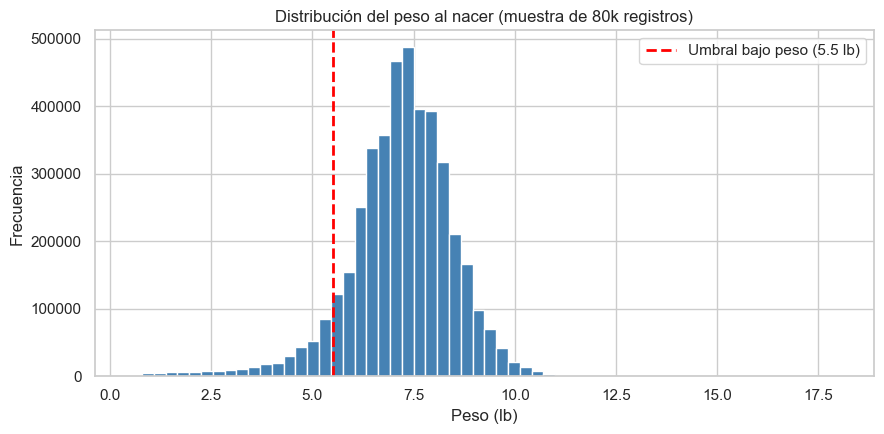

Proporción global de bebés con bajo peso (< 5.5 lb): 7.89%


In [13]:
# Distribución del peso al nacer con umbral clínico de bajo peso (5.5 lb)
UMBRAL_BAJO_PESO = 5.5

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(plot_df["weight_pounds"].dropna(), bins=60, color="steelblue", edgecolor="white")
ax.axvline(UMBRAL_BAJO_PESO, color="red", linestyle="--", linewidth=2,
           label=f"Umbral bajo peso ({UMBRAL_BAJO_PESO} lb)")
ax.set_title("Distribución del peso al nacer (muestra de 80k registros)")
ax.set_xlabel("Peso (lb)")
ax.set_ylabel("Frecuencia")
ax.legend()
plt.tight_layout()
plt.show()

pct_bajo_peso = (df_base["weight_pounds"] < UMBRAL_BAJO_PESO).mean() * 100
print(f"Proporción global de bebés con bajo peso (< {UMBRAL_BAJO_PESO} lb): {pct_bajo_peso:.2f}%")


### 3.4 Correlación de predictores numéricos con el peso

Calculamos la correlación de Spearman, más robusta a no linealidades, entre cada variable numérica y `weight_pounds`.

Observamos que `gestation_weeks` domina con 0.39, más del doble del siguiente predictor. En el rango medio positivo (~0.17) aparecen empatados `father_race`, `father_age` y `weight_gain_pounds`. `mother_age` aporta señal moderada (0.09) y `ever_born` queda casi nula (0.04). Las negativas las lidera `plurality` (-0.25), seguida de `mother_race` (-0.15), mientras que `cigarettes_per_day` cae al rango débil (-0.05).

A partir de esto podemos plantear que la prematuridad sigue siendo el driver principal del bajo peso, lo cual coincide con la literatura clínica. Los embarazos múltiples son la segunda fuente de variabilidad porque comparten el espacio uterino. El bloque del padre (raza y edad) y la ganancia de peso de la madre aparecen con magnitud y signo positivo similares, lo que sugiere que reflejan en parte un perfil de embarazos a término en familias con mayor estabilidad. Que `mother_race` y `father_race` muestren signos opuestos confirma que la correlación de Spearman sobre un código nominal es solo orientativa: el efecto real va a emerger tras el One-Hot, donde cada categoría se trata por separado.

A partir de esto construimos variables como `riesgo_prematuro` (gestation_weeks < 37) para que los modelos lineales capturen el quiebre clínico y volveremos a ver la correlación de estas nuevas variables con el peso del bebé al nacer.


Correlación Spearman con weight_pounds:


,corr
gestation_weeks,0.3852
weight_gain_pounds,0.1699
father_age,0.1699
mother_age,0.0850
ever_born,0.0382
cigarettes_per_day,-0.0529
plurality,-0.2509


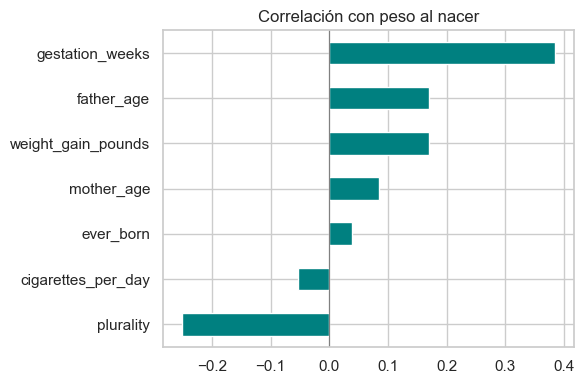

In [14]:
num_cols = df_base.select_dtypes(include=[np.number]).columns.tolist()
if "weight_pounds" in num_cols:
    num_cols.remove("weight_pounds")

corr_y = df_base[num_cols + ["weight_pounds"]].corr("spearman")["weight_pounds"].drop("weight_pounds").sort_values(ascending=False)
print("Correlación Spearman con weight_pounds:")
display(corr_y.to_frame("corr"))

plt.figure(figsize=(6, max(4, 0.35 * len(corr_y))))
corr_y.sort_values().plot(kind="barh", color="teal")
plt.axvline(0, color="gray", linewidth=0.8)
plt.title("Correlación con peso al nacer")
plt.tight_layout()
plt.show()

## 4. Ingeniería de características

Se construyen dos familias de variables:

- **Indicadores de reporte**: Con este buscamos convertir los faltantes en una señal explicita para el modelo de si hubo algún reporte de condiciones como el uso de cigarrillos o alcohol dentro del embarazo o la raza.

- **Variables de riesgo clínico/social**: Con estas buscamos codificar criterios usados en la literatura, como lo pueden ser la prematuridad, los embarazos múltiples, la edad de la madre, y la ganancia de peso.


### 4.1 Indicadores de reporte

| Nueva variable | Qué codifica |
|----------------|--------------|
| `cigarette_reported` | 1 si `cigarette_use` no es nulo; 0 si no hubo reporte. |
| `alcohol_reported` | Igual para alcohol. |
| `race_reported` | 1 si hay `mother_race` (proxy de captura). |
| `weight_gain_reported` | 1 si hay `weight_gain_pounds`. |

**Reglas** (cuando existan las columnas):

- Si `cigarette_use == False` y `cigarettes_per_day` es NA → **0** cigarrillos.

Con esto evitamos confundir el no consumo con los no reportados.


In [15]:
df_fe = df_base.copy()

if "cigarette_use" in df_fe.columns:
    df_fe["cigarette_reported"] = df_fe["cigarette_use"].notna().astype(np.int8)
if "alcohol_use" in df_fe.columns:
    df_fe["alcohol_reported"] = df_fe["alcohol_use"].notna().astype(np.int8)
if "mother_race" in df_fe.columns:
    df_fe["race_reported"] = df_fe["mother_race"].notna().astype(np.int8)
if "weight_gain_pounds" in df_fe.columns:
    df_fe["weight_gain_reported"] = df_fe["weight_gain_pounds"].notna().astype(np.int8)

if "cigarette_use" in df_fe.columns and "cigarettes_per_day" in df_fe.columns:
    mask = (df_fe["cigarette_use"] == False) & (df_fe["cigarettes_per_day"].isna())
    df_fe.loc[mask, "cigarettes_per_day"] = 0

report_cols = [c for c in ["cigarette_reported", "alcohol_reported", "race_reported", "weight_gain_reported"] if c in df_fe.columns]
if report_cols:
    display((df_fe[report_cols]*100).mean().round(2).to_frame("Porcentaje datos reportados"))

,Porcentaje datos reportados
cigarette_reported,34.9900
alcohol_reported,34.9900
race_reported,31.5600
weight_gain_reported,91.5500


### 4.2 Variables de riesgo clínico y social

Variables binarias interpretables que el modelo y el negocio pueden leer fácilmente:

| Variable | Definición | Por qué importa |
|----------|------------|-----------------|
| `riesgo_prematuro` | `gestation_weeks` < 37 | Prematuridad clínica. |
| `multiplo` | `plurality` > 1 | Indicador de embarazo múltiple |
| `madre_muy_joven` | `mother_age` < 20 | Indicador de maternidad temprana |
| `madre_mayor` | `mother_age` >= 35 | Indicador de maternidad geriatrica |
| `ganancia_baja_peso` | `weight_gain_pounds` < 15 lb | Indicador de poca ganancia de peso |
| `primigesta` | `ever_born` == 1 | Indicador de si la mamá es primeriza |
| `riesgo_social` | `mother_age` < 20 & `mother_married` = False | madre soltera + < 20 años |


In [16]:
if "gestation_weeks" in df_fe.columns:
    df_fe["riesgo_prematuro"] = (df_fe["gestation_weeks"] < 37).astype(np.int8)
if "plurality" in df_fe.columns:
    df_fe["multiplo"] = (df_fe["plurality"] > 1).astype(np.int8)
if "mother_age" in df_fe.columns:
    df_fe["madre_muy_joven"] = (df_fe["mother_age"] < 20).astype(np.int8)
    df_fe["madre_mayor"] = (df_fe["mother_age"] >= 35).astype(np.int8)
if "weight_gain_pounds" in df_fe.columns:
    df_fe["ganancia_baja_peso"] = (df_fe["weight_gain_pounds"] < 15).astype(np.int8)
    df_fe.loc[df_fe["weight_gain_pounds"].isna(), "ganancia_baja_peso"] = np.nan
if "ever_born" in df_fe.columns:
    df_fe["primigesta"] = (df_fe["ever_born"] == 1).astype(np.int8)
if "mother_married" in df_fe.columns and "mother_age" in df_fe.columns:
    mm = df_fe["mother_married"].astype("boolean")
    df_fe["riesgo_social"] = ((mm == False) & (df_fe["mother_age"] < 20)).astype(np.int8)

risk_cols = [c for c in ["riesgo_prematuro", "multiplo", "madre_muy_joven", "madre_mayor", "ganancia_baja_peso", "primigesta", "riesgo_social"] if c in df_fe.columns]
if risk_cols:
    display(df_fe[risk_cols].describe().T[["mean", "std"]])

,mean,std
riesgo_prematuro,0.1228,0.3282
multiplo,0.0341,0.1814
madre_muy_joven,0.1037,0.3048
madre_mayor,0.1419,0.3489
ganancia_baja_peso,0.0967,0.2955
primigesta,0.4012,0.4901
riesgo_social,0.0900,0.2862


### 4.3 Correlación de todas las variables con el peso

Para decidir qué variables dejar en el modelo, calculamos la correlación de Spearman de cada feature con `weight_pounds`. Incluimos tanto las variables originales del dataset como las que creamos en el feature enginieering, así podemos comparar en una misma vista qué aporta más y qué se podría descartar.

Esperamos ver en los primeros lugares (en valor absoluto) variables como `gestation_weeks` y `riesgo_prematuro`, y en los últimos las que aportan poca información y son candidatas a salir del modelo final.


Correlación:


,corr_con_peso
gestation_weeks,0.3852
riesgo_prematuro,-0.3643
plurality,-0.2509
multiplo,-0.2508
weight_gain_pounds,0.1699
father_age,0.1699
cigarettes_per_day,-0.1147
cigarette_use,-0.1140
alcohol_use,-0.1140
mother_married,0.1125


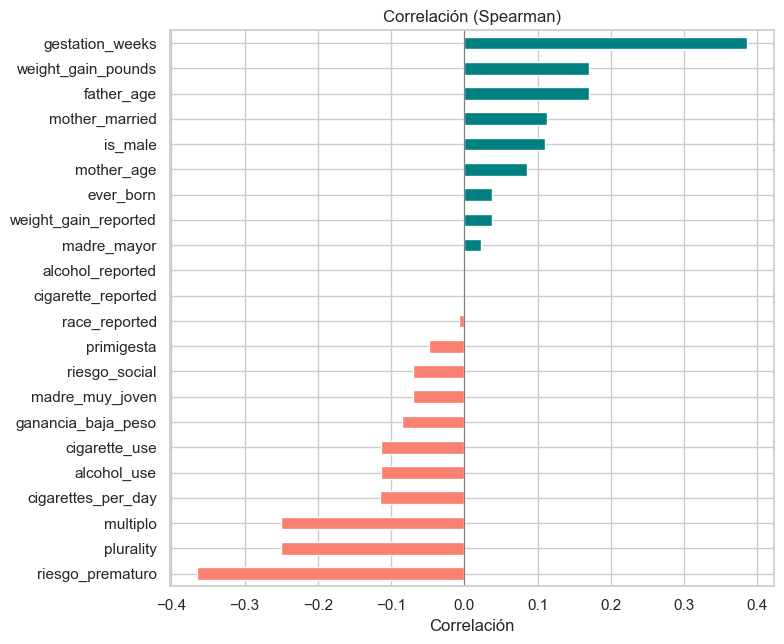

In [17]:
df_corr = df_fe.copy()

for col in df_corr.columns:
    s = df_corr[col]
    if s.dtype == bool or str(s.dtype) in ("boolean", "object"):
        mapped = s.map({True: 1.0, False: 0.0, "True": 1.0, "False": 0.0,
                        "TRUE": 1.0, "FALSE": 0.0})
        if mapped.notna().sum() == 0:
            mapped = pd.to_numeric(s, errors="coerce")
        df_corr[col] = mapped

num_all = df_corr.select_dtypes(include=[np.number]).columns.tolist()
num_all = [c for c in num_all if c != "weight_pounds"]

corr_all = (
    df_corr[num_all + ["weight_pounds"]]
    .corr("spearman")["weight_pounds"]
    .drop("weight_pounds")
)
corr_all = corr_all.reindex(corr_all.abs().sort_values(ascending=False).index)

print("Correlación:")
display(corr_all.to_frame("corr_con_peso"))

# Gráfico de barras horizontal coloreado por signo
colors = ["teal" if v >= 0 else "salmon" for v in corr_all.sort_values()]
plt.figure(figsize=(8, max(4, 0.3 * len(corr_all))))
corr_all.sort_values().plot(kind="barh", color=colors)
plt.axvline(0, color="gray", linewidth=0.8)
plt.title("Correlación (Spearman)")
plt.xlabel("Correlación")
plt.tight_layout()
plt.show()


### 4.4 Outliers y valores dummie
Para limitar el efecto de los valores extremos hacemos dos cosas. Primero acotamos las variables clínicas a rangos biológicamente plausibles: `weight_pounds` entre 1 y 14 libras, y `gestation_weeks` entre 24 y 45 semanas. Segundo aplicamos un recorte por IQR en `mother_age` y `weight_gain_pounds` para quitar colas extremas que no aportan al modelo. Los valores centinela tipo 99 o 9999 ya quedaron limpios al parsear `lmp` y al imponer los rangos biológicos.


In [18]:
def clip_bio(df, col_weight="weight_pounds", col_gest="gestation_weeks"):
    out = df.copy()
    if col_weight in out.columns:
        out = out[(out[col_weight] >= 1) & (out[col_weight] <= 14)]
    if col_gest in out.columns:
        out = out[(out[col_gest] >= 24) & (out[col_gest] <= 45)]
    return out


def drop_iqr(df, col, k=1.5):
    s = df[col].dropna()
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - k * iqr, q3 + k * iqr
    return df[(df[col].isna()) | ((df[col] >= lo) & (df[col] <= hi))]


df_fe = clip_bio(df_fe)
df_fe = drop_iqr(df_fe, "mother_age")
df_fe = drop_iqr(df_fe, "weight_gain_pounds")

### 4.5 Features finales para modelado V2 - A consideración, no eliminar algunas de las variables que en V1 se eliminaron

A partir del análisis de correlación (Spearman) y de las variables de riesgo clínico y social definidas en §4.2, definimos un único conjunto extendido de características que combina:

1. variables continuas con señal estadística clara,
2. indicadores binarios de riesgo clínico y social, y
3. variables categóricas que capturan diferencias poblacionales relevantes.

Este conjunto extendido está pensado para ser utilizado de forma consistente por todos los modelos, tanto lineales como no lineales (árboles y ensambles), priorizando un balance entre capacidad predictiva e interpretabilidad clínica.

**Variables continuas que mantenemos:**

- `gestation_weeks` (corr 0.39): es la variable más predictiva y la que tiene sentido biológico más directo, ya que a más semanas de gestación el bebé tiene más tiempo para desarrollarse y ganar peso. No puede faltar en el modelo.
- `plurality` (corr -0.25): los embarazos múltiples reducen sistemáticamente el peso individual de cada bebé porque comparten el mismo espacio uterino. Aporta una segunda fuente de señal independiente de la gestación.
- `weight_gain_pounds` (corr 0.17): la ganancia de peso de la madre durante el embarazo es un proxy directo del aporte nutricional al feto, lo cual la convierte en una variable accionable y clínicamente relevante.
- `cigarettes_per_day` (corr -0.11): cuantifica el consumo de tabaco con más detalle que el booleano `cigarette_use`. La elegimos sobre la versión binaria porque tiene más información y correlación ligeramente mejor.
- `mother_age` (corr 0.09): la edad de la madre tiene una relación en U con el peso al nacer (las maternidades muy tempranas y geriátricas son de mayor riesgo). La dejamos como continua para que los modelos de árbol puedan capturar esa forma no lineal por sí solos.
- `father_age` (corr 0.17): aparece con la misma magnitud que la ganancia de peso de la madre y con signo positivo, posiblemente como proxy de estabilidad familiar y acceso a controles prenatales. La incluimos porque aporta una señal complementaria a las variables maternas.

**Variables booleanas que mantenemos:**

- `alcohol_use` (corr -0.11): es la única señal de consumo de alcohol que sobrevive porque `drinks_per_week` quedó con 100% de nulos. La conservamos pese a su alta tasa de faltantes porque cuando se reporta sí discrimina.
- `mother_married` (corr 0.11): es un proxy del entorno socioeconómico y de la red de apoyo durante el embarazo, y aparece con correlación estable, así que aporta una dimensión social que las otras variables no cubren.
- `is_male` (corr 0.11): el sexo del bebé tiene un efecto pequeño pero consistente sobre el peso al nacer, según esto los niños pesan en promedio un poco más que las niñas.
- `riesgo_prematuro`: indicador binario de gestación < 37 semanas. Aunque es función directa de gestation_weeks, lo mantenemos porque codifica explícitamente el umbral clínico de prematuridad y aporta una no linealidad relevante, especialmente para modelos lineales.
- `multiplo`: se define a partir de plurality > 1 y resume el hecho clínico de “embarazo múltiple” como tal. Conservamos tanto plurality como multiplo porque la variable continua captura el número de fetos, mientras que la binaria representa directamente el escenario de riesgo.
- `madre_muy_joven`: identifica gestantes menores de 20 años. Aunque la edad ya está incluida como continua, este umbral hace explícito un grupo de alto riesgo reconocido en la literatura.
- `madre_mayor`: marca gestantes de 35 años o más, segmento asociado a mayor frecuencia de complicaciones obstétricas y bajo peso al nacer.
- `ganancia_baja_peso`: indica una ganancia de peso materna inferior a 15 libras. Complementa a weight_gain_pounds resaltando directamente el patrón de bajo aumento de peso, de interés clínico.
- `primigesta`: identifica a las madres en su primer embarazo vivo (ever_born == 1). Aunque la paridad como continua tiene poca correlación global con el peso, esta categoría puede ayudar a perfilar subgrupos de riesgo en los modelos no lineales.
- `riesgo_social`: combina dos factores —no estar casada y ser madre muy joven— para capturar un entorno social potencialmente más vulnerable, con posibles carencias de apoyo y de acceso oportuno a controles prenatales.

**Variables categóricas que mantenemos:**

- `mother_race` y `father_race`: capturan diferencias fisiológicas documentadas en el peso neonatal entre grupos étnicos que persisten incluso a igual edad gestacional.

**Variable derivada que mantenemos:**

- `riesgo_prematuro` (corr -0.36): aunque es función directa de `gestation_weeks`, la dejamos porque codifica el quiebre clínico de las 37 semanas y aporta no linealidad a los modelos lineales.

**Variables descartadas y por qué:**
Se descartaron indicadores puramente técnicos de reporte (cigarette_reported, alcohol_reported, race_reported, weight_gain_reported) porque, pese a la hipótesis inicial de que la ausencia de datos pudiera ser una señal de riesgo, su correlación con el peso al nacer es prácticamente nula y no aportan mejora observable en el poder predictivo. Asimismo, se excluye cigarette_use frente a cigarettes_per_day, al ser redundante y menos informativa.

**Conjunto final de features**

Con estas decisiones trabajamos con un único conjunto extendido de características que incluye:

6 variables continuas:
`gestation_weeks`, `plurality`, `weight_gain_pounds`, `cigarettes_per_day`, `mother_age`, `father_age`.

10 variables booleanas de riesgo clínico y social:
`alcohol_use`, `mother_married`, `is_male`, `riesgo_prematuro`,
`multiplo`, `madre_muy_joven`, `madre_mayor`, `ganancia_baja_peso`,
`primigesta`, `riesgo_social`.

2 variables categóricas:
`mother_race`, `father_race`.

En total, el modelo se entrena sobre 18 features. Este set extendido permite capturar tanto efectos monotónicos globales (a través de las variables continuas) como cortes clínicos y sociales relevantes (a través de las variables de riesgo), y se utiliza de forma consistente en todos los modelos que se describen en §5.

In [19]:
FINAL_FEATURES = [
    # Continuas
    "gestation_weeks",
    "plurality",
    "weight_gain_pounds",
    "cigarettes_per_day",
    "mother_age",
    "father_age",

    # Booleanas / binarias de riesgo clínico y social
    "alcohol_use",
    "mother_married",
    "is_male",
    "riesgo_prematuro",
    "multiplo",
    "madre_muy_joven",
    "madre_mayor",
    "ganancia_baja_peso",
    "primigesta",
    "riesgo_social",

    # Categóricas
    "mother_race",
    "father_race",
]

cols_to_keep = [c for c in FINAL_FEATURES if c in df_fe.columns] + ["weight_pounds"]
df_fe = df_fe[cols_to_keep].copy()

for col in ["father_race", "mother_race"]:
    if col in df_fe.columns:
        df_fe[col] = df_fe[col].astype("category")

X_cols = [c for c in df_fe.columns if c != "weight_pounds"]
print(f"Features finales: {len(X_cols)}")
print(X_cols)

Features finales: 18
['gestation_weeks', 'plurality', 'weight_gain_pounds', 'cigarettes_per_day', 'mother_age', 'father_age', 'alcohol_use', 'mother_married', 'is_male', 'riesgo_prematuro', 'multiplo', 'madre_muy_joven', 'madre_mayor', 'ganancia_baja_peso', 'primigesta', 'riesgo_social', 'mother_race', 'father_race']


## 5. Modelado

La variable `weight_pounds` es continua. Un clasificador binario (bajo peso sí/no) solo respondería si el bebé entra o no en cuidado especializado, pero escogimos la regresión porque nos dice qué tan por debajo del umbral está el peso del bebé, lo cual permite calibrar la severidad del cuidado y agregar pronósticos para planeación de recursos. Además, la base está muy desbalanceada, apenas 8% de bajo peso, lo cual penaliza el desempeño de los clasificadores estándar, mientras que la regresión usa toda la masa de la distribución.

Reportamos dos métricas alineadas con el negocio:

- **MAPE** (error porcentual absoluto medio): mide el error relativo promedio. Es escala-invariante y fácil de comunicar a negocio ("el modelo se equivoca en promedio X% del peso real").

- **% dentro de ±10%**: mide la proporción de predicciones lo suficientemente precisas para tomar la decisión operativa. Responde directamente a la pregunta de la EPS: *¿con qué frecuencia el modelo me da un estimado lo suficientemente bueno para asignar el cuidado correcto?*

Descartamos R² porque sobre una variable con poca varianza relativa (la mayoría de bebés pesan entre 6 y 8 libras) su valor no es intuitivo para decisiones operativas.

Cubrimos cinco familias para tener un panorama amplio entre interpretabilidad y capacidad predictiva: dos lineales (Regresión Lineal y Elastic Net), tres ensambles de árboles (Random Forest, XGBoost y LightGBM), un SVM lineal y una red neuronal. Todos usan el mismo dataset construido y el mismo split train/val/test. **Evaluamos en train y test** para detectar overfitting.


In [21]:
import sys
!{sys.executable} -m pip install xgboost lightgbm

  Using cached xgboost-3.2.0-py3-none-win_amd64.whl.metadata (2.1 kB)
Using cached xgboost-3.2.0-py3-none-win_amd64.whl (101.7 MB)
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------- ----------- 1.0/1.5 MB 7.0 MB/s eta 0:00:01
   ---------------------------------------- 1.5/1.5 MB 6.6 MB/s  0:00:00

   ---------------------------------------- 0/2 [xgboost]
   ---------------------------------------- 0/2 [xgboost]
   ---------------------------------------- 0/2 [xgboost]
   ---------------------------------------- 0/2 [xgboost]
   ---------------------------------------- 0/2 [xgboost]
   ---------------------------------------- 0/2 [xgboost]
   ---------------------------------------- 0/2 [xgboost]
   ---------------------------------------- 2/2 [lightgbm]



In [22]:
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

In [23]:
import warnings

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import ElasticNetCV, LinearRegression
from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import LinearSVR
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
from sklearn.base import clone
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

plt.style.use("seaborn-v0_8-whitegrid")

N_SAMPLE_REG = 400_000

In [24]:
from sklearn.model_selection import train_test_split as _tts


def get_X_y(df, mode):
    drop_y = {"weight_pounds"}
    X = df.drop(columns=[c for c in drop_y if c in df.columns], errors="ignore")
    y = df["weight_pounds"]
    return X, y


def train_val_test_split(
    X,
    y,
    test_size=0.15,
    val_size=0.15,
    stratify=None,
    random_state=42,
):
    from sklearn.model_selection import train_test_split as tts

    X_temp, X_test, y_temp, y_test = tts(
        X,
        y,
        test_size=test_size,
        stratify=stratify,
        random_state=random_state,
    )
    val_rel = val_size / (1.0 - test_size)
    strat2 = y_temp if stratify is not None else None
    X_train, X_val, y_train, y_val = tts(
        X_temp,
        y_temp,
        test_size=val_rel,
        stratify=strat2,
        random_state=random_state,
    )
    return X_train, X_val, X_test, y_train, y_val, y_test


def detect_feature_types(X):
    num_cols = []
    cat_cols = []
    for c in X.columns:
        s = X[c]
        dt = s.dtype
        if pd.api.types.is_bool_dtype(dt) or str(dt) == "boolean":
            cat_cols.append(c)
        elif pd.api.types.is_numeric_dtype(dt):
            num_cols.append(c)
        else:
            cat_cols.append(c)
    return num_cols, cat_cols


def regression_scores(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    # MAPE (Mean Absolute Percentage Error)
    mask = y_true != 0
    mape = float(np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100)
    # % de predicciones dentro de ±10% del valor real
    pct_within_10 = float(np.mean(np.abs((y_pred - y_true) / np.where(y_true == 0, 1, y_true)) <= 0.10) * 100)
    return {
        "MAPE_%": round(mape, 2),
        "dentro_10%": round(pct_within_10, 2),
    }


_df = df_fe.copy()
if len(_df) > N_SAMPLE_REG:
    df_reg = _df.sample(n=N_SAMPLE_REG, random_state=RNG).reset_index(drop=True)
else:
    df_reg = _df.copy()

Xr, yr = get_X_y(df_reg, "regression")
num_r, cat_r = detect_feature_types(Xr)
print("Regresión — filas:", len(yr), "| num:", len(num_r), "cat:", len(cat_r))


Regresión — filas: 400000 | num: 13 cat: 5


In [25]:
def _one_hot_encoder():
    try:
        return OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False,
            drop="if_binary",
        )
    except TypeError:
        return OneHotEncoder(
            handle_unknown="ignore",
            sparse=False,
            drop="if_binary",
        )


def make_prep_linear(num_cols, cat_cols):
    transformers = []
    if num_cols:
        transformers.append(
            (
                "num",
                Pipeline(
                    [
                        ("imputer", SimpleImputer(strategy="median")),
                        ("scaler", StandardScaler()),
                    ]
                ),
                num_cols,
            )
        )
    if cat_cols:
        transformers.append(
            (
                "cat",
                Pipeline(
                    [
                        ("imputer", SimpleImputer(strategy="most_frequent")),
                        ("ohe", _one_hot_encoder()),
                    ]
                ),
                cat_cols,
            )
        )
    return ColumnTransformer(transformers, remainder="drop")


def make_prep_tree(num_cols, cat_cols):
    transformers = []
    if num_cols:
        transformers.append(("num", SimpleImputer(strategy="median"), num_cols))
    if cat_cols:
        transformers.append(
            (
                "cat",
                Pipeline(
                    [
                        ("imputer", SimpleImputer(strategy="most_frequent")),
                        ("ohe", _one_hot_encoder()),
                    ]
                ),
                cat_cols,
            )
        )
    return ColumnTransformer(transformers, remainder="drop")


def get_feature_names_safe(pipe, X_cols):
    prep = pipe.named_steps.get("prep") or pipe.named_steps.get("columntransformer")
    if prep is None:
        return [f"f{i}" for i in range(1000)]
    try:
        return list(prep.get_feature_names_out())
    except Exception:
        return [f"f{i}" for i in range(100)]


def plot_top_importance(names, values, title, ax=None, top=20):
    if ax is None:
        _, ax = plt.subplots(figsize=(8, max(4, top * 0.22)))
    order = np.argsort(np.abs(values))[-top:]
    ax.barh(np.array(names)[order], np.array(values)[order], color="steelblue")
    ax.set_title(title)
    ax.set_xlabel("Importancia / |coef.|")
    return ax


results_reg = []


### 5.1 Split train / val / test

Dividimos los datos en train (70%), validación (15%) y test (15%) con `random_state` fijo para que los resultados sean reproducibles.


In [26]:
X_train_r, X_val_r, X_test_r, y_train_r, y_val_r, y_test_r = train_val_test_split(
    Xr, yr, test_size=0.15, val_size=0.15, stratify=None, random_state=RNG
)
prep_lin_r = make_prep_linear(num_r, cat_r)
prep_tree_r = make_prep_tree(num_r, cat_r)
print("Regresión — train/val/test:", len(y_train_r), len(y_val_r), len(y_test_r))


Regresión — train/val/test: 279999 60001 60000


### 5.2 Modelo 1 — Regresión lineal (OLS)

Usamos OLS como baseline. Los coeficientes, en escala estandarizada, nos dicen qué tanto mueve el peso predicho cada feature.


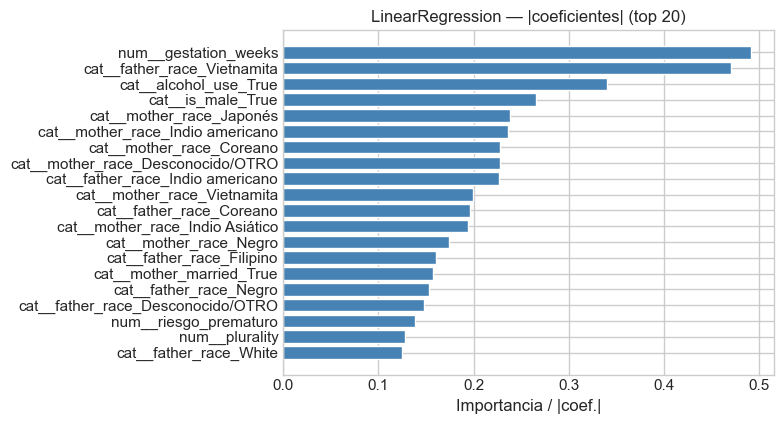

   MAPE_%  dentro_10%            modelo particion
0 12.0000     55.8200  LinearRegression     train
1 12.0400     55.4200  LinearRegression      test


In [27]:
name = "LinearRegression"
pipe = Pipeline([("prep", clone(prep_lin_r)), ("model", LinearRegression())])
pipe.fit(X_train_r, y_train_r)

for part, Xp, yp in [
    ("train", X_train_r, y_train_r),
    ("test", X_test_r, y_test_r),
]:
    pred = pipe.predict(Xp)
    m = regression_scores(yp, pred)
    m.update({"modelo": name, "particion": part})
    results_reg.append(m)

coef = pipe.named_steps["model"].coef_
fn = get_feature_names_safe(pipe, Xr.columns)
imp = np.abs(coef)[: len(fn)]
plot_top_importance(fn[: len(imp)], imp, f"{name} — |coeficientes| (top 20)", top=20)
plt.tight_layout()
plt.show()
print(pd.DataFrame(results_reg).query("modelo == @name"))


### 5.3 Modelo 2 — Regresión Lineal con Regularización

Para mejorar la capacidad de generalización del modelo lineal y controlar el sobreajuste, se estimó una regresión ElasticNet, que combina penalización L1 (Lasso) y L2 (Ridge) sobre los coeficientes. En lugar de ajustar los hiperparámetros sobre todo el conjunto de entrenamiento, se realizó una búsqueda en grilla utilizando una submuestra estratificada de 200.000 registros, manteniendo la proporción original de recién nacidos con bajo peso y peso no bajo. Sobre esta submuestra se exploró una grilla acotada de valores para los parámetros alpha (intensidad de la regularización) y l1_ratio (peso relativo entre L1 y L2), empleando validación cruzada de 5 folds y utilizando el MAPE como métrica objetivo.

Una vez identificada la combinación de hiperparámetros que minimizó el error porcentual absoluto medio en la validación cruzada, se reentrenó el modelo ElasticNet final sobre todo el conjunto de entrenamiento, aplicando el mismo pipeline de preprocesamiento que en la regresión lineal simple. Posteriormente, el desempeño del modelo se evaluó en las particiones de entrenamiento y prueba, reportando el MAPE_% y el porcentaje de predicciones dentro de un ±10% del peso real al nacer, con el fin de comparar directamente este modelo regularizado frente a la regresión lineal sin penalización y a los demás modelos considerados.

**Espacio de búsqueda:**
- `alpha` ∈ {0.001, 0.01, 0.1, 0.5} 
- `l1_ratio` ∈ {0.1, 0.5, 0.75, 0.9} 
- `cv` = 5, `scoring` = neg_mean_absolute_percentage_error


Proporción bajo peso en train: 0.07663955942699795
Tamaño tuning: 200000
Proporción bajo peso en tuning: 0.07664
Fitting 5 folds for each of 16 candidates, totalling 80 fits
Mejores hiperparámetros: {'model__alpha': 0.001, 'model__l1_ratio': 0.1}
Mejor score (neg MAPE): -0.12008723796397676


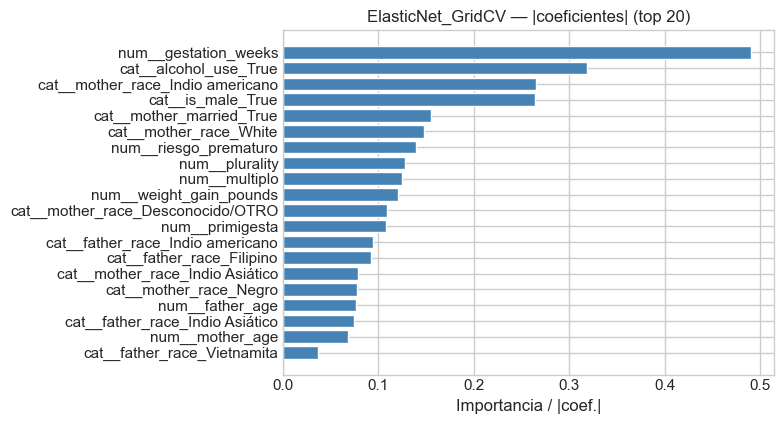

,MAPE_%,dentro_10%,modelo,particion
2,12.0000,55.8200,ElasticNet_GridCV,train
3,12.0500,55.4400,ElasticNet_GridCV,test
4,12.0100,55.8200,ElasticNet_GridCV,train
5,12.0500,55.4300,ElasticNet_GridCV,test
6,12.0000,55.8200,ElasticNet_GridCV,train
7,12.0500,55.4400,ElasticNet_GridCV,test
8,12.0000,55.8200,ElasticNet_GridCV,train
9,12.0500,55.4400,ElasticNet_GridCV,test


In [33]:
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import GridSearchCV, StratifiedShuffleSplit

name = "ElasticNet_GridCV"

# -------------------------------------------------------------------
# 1. Definir etiqueta binaria de bajo peso para estratificar
# -------------------------------------------------------------------
THRESH_LOW_WEIGHT = 5.5  # o el umbral clínico que se decida

y_train_low = (y_train_r < THRESH_LOW_WEIGHT).astype(int)

print("Proporción bajo peso en train:", y_train_low.mean())

# -------------------------------------------------------------------
# 2. Submuestra estratificada solo para el tuning
# -------------------------------------------------------------------
N_TUNING = 200_000  # 

sss = StratifiedShuffleSplit(
    n_splits=1,
    train_size=min(N_TUNING, len(X_train_r)),
    random_state=RNG,
)

for idx_sub, _ in sss.split(X_train_r, y_train_low):
    X_tune = X_train_r.iloc[idx_sub].copy()
    y_tune = y_train_r.iloc[idx_sub].copy()
    y_tune_low = y_train_low.iloc[idx_sub].copy()

print("Tamaño tuning:", X_tune.shape[0])
print("Proporción bajo peso en tuning:", y_tune_low.mean())

# -------------------------------------------------------------------
# 3. Definir pipeline base y grilla reducida
# -------------------------------------------------------------------
pipe_base = Pipeline(
    [
        ("prep", clone(prep_lin_r)),
        ("model", ElasticNet(random_state=RNG, max_iter=10000)),
    ]
)

param_grid = {
    "model__alpha": [0.001, 0.01, 0.1, 0.5],
    "model__l1_ratio": [0.1, 0.5, 0.75, 0.9],
}


grid_search = GridSearchCV(
    pipe_base,
    param_grid,
    cv=5,
    scoring="neg_mean_absolute_percentage_error",
    n_jobs=-1,
    verbose=1,
    return_train_score=True,
)

# -------------------------------------------------------------------
# 4. Ajustar la grilla sobre la submuestra
# -------------------------------------------------------------------
grid_search.fit(X_tune, y_tune)

print("Mejores hiperparámetros:", grid_search.best_params_)
print("Mejor score (neg MAPE):", grid_search.best_score_)

# -------------------------------------------------------------------
# 5. Entrenar modelo final con mejores hiperparámetros en TODO el train
# -------------------------------------------------------------------
best_alpha = grid_search.best_params_["model__alpha"]
best_l1 = grid_search.best_params_["model__l1_ratio"]

pipe_enet = Pipeline(
    [
        ("prep", clone(prep_lin_r)),
        ("model", ElasticNet(
            alpha=best_alpha,
            l1_ratio=best_l1,
            random_state=RNG,
            max_iter=10000,
        )),
    ]
)

pipe_enet.fit(X_train_r, y_train_r)

# -------------------------------------------------------------------
# 6. Evaluar en train y test con mismas métricas que el resto
# -------------------------------------------------------------------
for part, Xp, yp in [
    ("train", X_train_r, y_train_r),
    ("test", X_test_r, y_test_r),
]:
    pred = pipe_enet.predict(Xp)
    m = regression_scores(yp, pred)
    m.update({"modelo": name, "particion": part})
    results_reg.append(m)

# Importancias (coeficientes)
coef = pipe_enet.named_steps["model"].coef_
fn = get_feature_names_safe(pipe_enet, Xr.columns)
imp = np.abs(coef)[: len(fn)]

plot_top_importance(
    fn[: len(imp)],
    imp,
    f"{name} — |coeficientes| (top 20)",
    top=20,
)
plt.tight_layout()
plt.show()

pd.DataFrame(results_reg).query("modelo == @name")

In [34]:
# Mejor modelo y sus hiperparámetros
print("="*60)
print("MEJORES HIPERPARÁMETROS ENCONTRADOS:")
print(f"  alpha:    {grid_search.best_params_['model__alpha']}")
print(f"  l1_ratio: {grid_search.best_params_['model__l1_ratio']}")
print(f"  Mejor MAPE (CV): {-grid_search.best_score_*100:.4f}%")
print("="*60)

# Usar el mejor pipeline encontrado
pipe = grid_search.best_estimator_

for part, Xp, yp in [
    ("train", X_train_r, y_train_r),
    ("test", X_test_r, y_test_r),
]:
    pred = pipe.predict(Xp)
    m = regression_scores(yp, pred)
    m.update({"modelo": name, "particion": part})
    results_reg.append(m)

MEJORES HIPERPARÁMETROS ENCONTRADOS:
  alpha:    0.001
  l1_ratio: 0.1
  Mejor MAPE (CV): 12.0087%


In [35]:
# --- Importancia de variables (|coeficientes|) ---
coef = np.abs(pipe.named_steps["model"].coef_)
fn = get_feature_names_safe(pipe, Xr.columns)
fn_arr = np.array(fn[: len(coef)])

# Ordenar por importancia descendente
sorted_idx = np.argsort(coef)[::-1]
top_n = 20

print(f"\n{'='*60}")
print(f"TOP {top_n} VARIABLES MÁS RELEVANTES PARA EL MODELO:")
print(f"{'='*60}")
for i, idx in enumerate(sorted_idx[:top_n], 1):
    print(f"  {i:2d}. {fn_arr[idx]:<35s} |coef| = {coef[idx]:.6f}")

# Variables con coeficiente cero (eliminadas por regularización L1)
n_zero = np.sum(coef == 0)
print(f"\nVariables eliminadas (coef=0): {n_zero} de {len(coef)}")
print(f"Variables seleccionadas:        {len(coef) - n_zero} de {len(coef)}")


TOP 20 VARIABLES MÁS RELEVANTES PARA EL MODELO:
   1. num__gestation_weeks                |coef| = 0.490518
   2. cat__alcohol_use_True               |coef| = 0.336678
   3. cat__is_male_True                   |coef| = 0.265739
   4. cat__mother_race_Indio americano    |coef| = 0.236895
   5. cat__mother_married_True            |coef| = 0.152033
   6. cat__mother_race_White              |coef| = 0.146620
   7. num__riesgo_prematuro               |coef| = 0.140552
   8. num__plurality                      |coef| = 0.129892
   9. num__multiplo                       |coef| = 0.122514
  10. num__weight_gain_pounds             |coef| = 0.119479
  11. cat__father_race_Indio americano    |coef| = 0.113700
  12. num__primigesta                     |coef| = 0.107021
  13. cat__mother_race_Desconocido/OTRO   |coef| = 0.095613
  14. cat__father_race_Filipino           |coef| = 0.087899
  15. cat__father_race_Indio Asiático     |coef| = 0.084064
  16. num__father_age                     |coef| = 

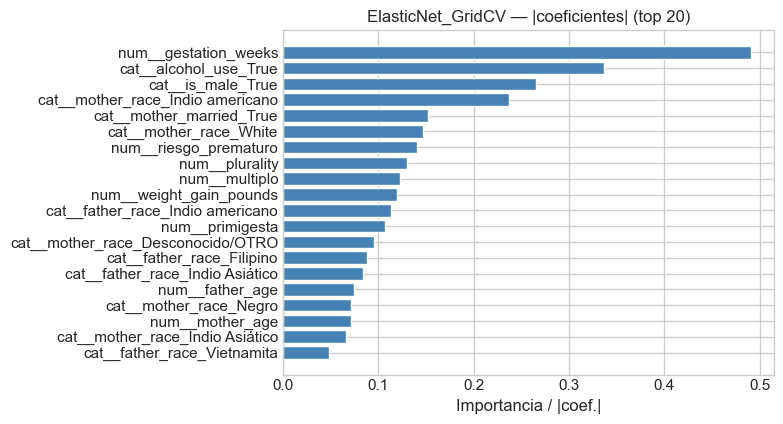


Resultados del modelo:
    MAPE_%  dentro_10%             modelo particion
2  12.0000     55.8200  ElasticNet_GridCV     train
3  12.0500     55.4400  ElasticNet_GridCV      test
4  12.0100     55.8200  ElasticNet_GridCV     train
5  12.0500     55.4300  ElasticNet_GridCV      test
6  12.0000     55.8200  ElasticNet_GridCV     train
7  12.0500     55.4400  ElasticNet_GridCV      test
8  12.0000     55.8200  ElasticNet_GridCV     train
9  12.0500     55.4400  ElasticNet_GridCV      test
10 12.0000     55.8200  ElasticNet_GridCV     train
11 12.0500     55.4400  ElasticNet_GridCV      test


In [36]:
# Gráfico de importancia
plot_top_importance(fn[: len(coef)], coef, f"{name} — |coeficientes| (top 20)", top=20)
plt.tight_layout()
plt.show()

print("\nResultados del modelo:")
print(pd.DataFrame(results_reg).query("modelo == @name"))

Las semanas de gestación dominan la predicción, seguidas por alcohol, sexo, si la raza de la madre es de indio americano. Con estas 4 variables se captura la mayor parte de la señal. El alcohol es el único factor modificable del top 5, lo que justifica programas de intervención temprana. Las diferencias por grupo étnico señalan poblaciones donde reforzar el acompañamiento prenatal.

In [37]:
import joblib

joblib.dump(grid_search.best_estimator_, "elasticnet_model.pkl")

print(f"Modelo guardado en: elasticnet_model.pkl")
print(f"Mejores hiperparámetros: {grid_search.best_params_}")
print(f"Mejor MAPE (CV): {-grid_search.best_score_*100:.4f}%")


Modelo guardado en: elasticnet_model.pkl
Mejores hiperparámetros: {'model__alpha': 0.001, 'model__l1_ratio': 0.1}
Mejor MAPE (CV): 12.0087%


### 5.4 Modelo 3 — Random Forest (RandomizedSearchCV)

Ensamble de árboles entrenados con bootstrap. Captura no linealidades e interacciones sin ingeniería explícita, y su importancia de variables es fácil de comunicar. Se realiza una búsqueda exhaustiva de hiperparámetros con `RandomizedSearchCV` optimizando directamente el **MAPE negativo** para encontrar la mejor combinación de parámetros. Usamos búsqueda aleatoria en lugar de grid completo porque el espacio de hiperparámetros del Random Forest es muy grande y un grid exhaustivo sería computacionalmente prohibitivo.

**Espacio de búsqueda:**
- `n_estimators` ∈ {50, 100, 150, 200}
- `max_depth` ∈ {8, 12, 16, 20, None}
- `min_samples_split` ∈ {2, 5, 10, 20}
- `min_samples_leaf` ∈ {1, 10, 25, 50, 100}
- `max_features` ∈ {'sqrt', 'log2', 0.5, 1.0}
- `n_iter` = 30, `cv` = 3, `scoring` = neg_mean_absolute_percentage_error


In [38]:
name = "RandomForest_RandCV"

# Pipeline base con preprocesamiento de árboles + RandomForest
pipe_base_rf = Pipeline(
    [
        ("prep", clone(prep_tree_r)),
        ("model", RandomForestRegressor(random_state=RNG, n_jobs=-1)),
    ]
)

In [39]:
# Espacio de hiperparámetros: cubrir desde árboles cortos hasta profundos
param_dist_rf = {
    "model__n_estimators": [50, 100, 150, 200],
    "model__max_depth": [8, 12, 16, 20, None],
    "model__min_samples_split": [2, 5, 10, 20],
    "model__min_samples_leaf": [1, 10, 25, 50, 100],
    "model__max_features": ["sqrt", "log2", 0.5, 1.0],
}

In [40]:
# RandomizedSearchCV optimizando MAPE (negativo porque sklearn maximiza)
rand_search_rf = RandomizedSearchCV(
    pipe_base_rf,
    param_distributions=param_dist_rf,
    n_iter=30,
    cv=3,
    scoring="neg_mean_absolute_percentage_error",
    n_jobs=-1,
    verbose=1,
    random_state=RNG,
    return_train_score=True,
)

rand_search_rf.fit(X_train_r, y_train_r)

# Mostrar mejores hiperparámetros
print("=" * 60)
print("MEJORES HIPERPARÁMETROS ENCONTRADOS:")  
for param, value in rand_search_rf.best_params_.items():
    print(f"  {param.replace('model__', ''):<20s}: {value}")
print(f"  Mejor MAPE (CV): {-rand_search_rf.best_score_*100:.4f}%")
print("=" * 60)

Fitting 3 folds for each of 30 candidates, totalling 90 fits
MEJORES HIPERPARÁMETROS ENCONTRADOS:
  n_estimators        : 100
  min_samples_split   : 5
  min_samples_leaf    : 1
  max_features        : 0.5
  max_depth           : 12
  Mejor MAPE (CV): 11.4502%


El Random Forest ajustado mediante RandomizedSearchCV seleccionó un bosque de alrededor de 100 árboles, con profundidad máxima 12, muestreo del 50% de las variables por split y requisitos mínimos de 5 observaciones para dividir un nodo. Esta configuración logra un MAPE medio de validación cruzada cercano al 11.45%, manteniendo un equilibrio entre complejidad del modelo y capacidad de generalización

In [41]:
# Usar el mejor pipeline encontrado y evaluarlo en train/test
pipe = rand_search_rf.best_estimator_

for part, Xp, yp in [
    ("train", X_train_r, y_train_r),
    ("test", X_test_r, y_test_r),
]:
    pred = pipe.predict(Xp)
    m = regression_scores(yp, pred)
    m.update({"modelo": name, "particion": part})
    results_reg.append(m)

print("Resultados del modelo:")
print(pd.DataFrame(results_reg).query("modelo == @name"))

Resultados del modelo:
    MAPE_%  dentro_10%               modelo particion
12 11.1000     57.2600  RandomForest_RandCV     train
13 11.4500     56.3100  RandomForest_RandCV      test


TOP 20 VARIABLES MÁS RELEVANTES PARA EL MODELO:
   1. num__gestation_weeks                importancia = 0.537763
   2. num__riesgo_prematuro               importancia = 0.161994
   3. num__multiplo                       importancia = 0.063007
   4. num__plurality                      importancia = 0.044833
   5. num__weight_gain_pounds             importancia = 0.034763
   6. num__father_age                     importancia = 0.034593
   7. num__mother_age                     importancia = 0.030365
   8. cat__is_male_True                   importancia = 0.027925
   9. num__primigesta                     importancia = 0.018446
  10. cat__mother_married_True            importancia = 0.014743
  11. num__cigarettes_per_day             importancia = 0.006973
  12. cat__mother_race_Negro              importancia = 0.003361
  13. cat__mother_race_White              importancia = 0.002918
  14. cat__alcohol_use_True               importancia = 0.002769
  15. cat__father_race_White              

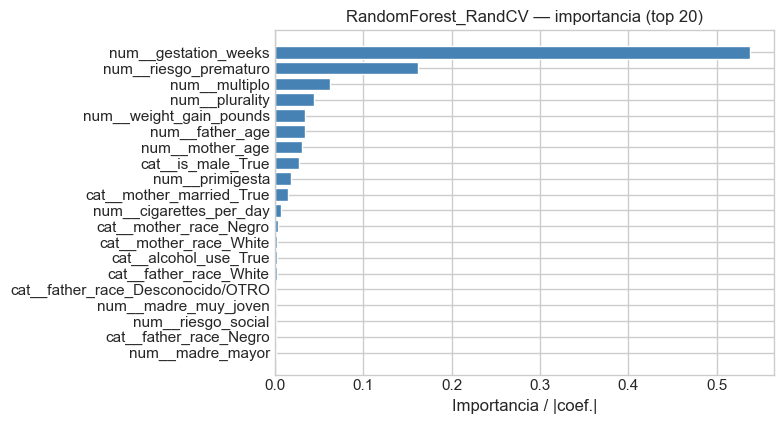

In [42]:
# --- Importancia de variables ---
fn = get_feature_names_safe(pipe, Xr.columns)
imp = pipe.named_steps["model"].feature_importances_
fn_arr = np.array(fn[: len(imp)])

# Ordenar por importancia descendente
sorted_idx = np.argsort(imp)[::-1]
top_n = 20

print(f"{'='*60}")
print(f"TOP {top_n} VARIABLES MÁS RELEVANTES PARA EL MODELO:")
print(f"{'='*60}")
for i, idx in enumerate(sorted_idx[:top_n], 1):
    print(f"  {i:2d}. {fn_arr[idx]:<35s} importancia = {imp[idx]:.6f}")

# Gráfico de importancia
plot_top_importance(fn[: len(imp)], imp, f"{name} — importancia (top 20)", top=20)
plt.tight_layout()
plt.show()

El análisis de importancia de variables del Random Forest muestra que la duración de la gestación es, con diferencia, el predictor más relevante del peso al nacer, concentrando más de la mitad de la importancia total del modelo. En segundo y tercer lugar aparecen las variables derivadas de riesgo clínico “riesgo_prematuro” y “multiplo”, que capturan la probabilidad de parto pretérmino y la presencia de embarazo múltiple, ambos factores estrechamente asociados a bajo peso al nacer en la literatura clínica.

Entre el cuarto y octavo lugar se destacan variables obstétricas y sociodemográficas que modulan el crecimiento fetal: la pluralidad, la ganancia de peso materno durante el embarazo, la edad del padre y de la madre, así como el sexo del recién nacido, donde los varones tienden a presentar pesos ligeramente mayores. Más abajo en el ranking aparecen factores de historia reproductiva y contexto social, como primigesta y madre casada, junto con los indicadores de consumo de cigarrillos y alcohol; aunque su importancia numérica es menor, el modelo los utiliza como moduladores adicionales del riesgo. Finalmente, las categorías de raza de la madre y del padre y las variables de madre muy joven, madre mayor y riesgo_social aportan información marginal que ayuda a afinar la predicción, pero su peso relativo es reducido frente a las variables gestacionales y de riesgo clínico directo.

En conjunto, estos resultados son consistentes con la evidencia clínica: el peso al nacer está dominado por la edad gestacional y por condiciones que aumentan el riesgo de prematuridad o embarazo múltiple, mientras que factores de estilo de vida y contexto social actúan como moduladores secundarios del riesgo más que como determinantes principales del peso del recién nacido.

### 5.5 Modelo 4 — XGBoost

Gradient boosting que entrena árboles secuencialmente corrigiendo los errores del modelo anterior. Suele dar el mejor trade-off entre precisión y tiempo en tabulares. 

In [48]:
from xgboost import XGBRegressor  # o GradientBoostingRegressor si usas sklearn
from sklearn.model_selection import RandomizedSearchCV, StratifiedShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.base import clone

# -------------------------------------------------------------------
# 1. Submuestra estratificada para el tuning (misma lógica que RF)
# -------------------------------------------------------------------
THRESH_LOW_WEIGHT = 5.5
y_train_low = (y_train_r < THRESH_LOW_WEIGHT).astype(int)

N_TUNING = 200_000

sss = StratifiedShuffleSplit(n_splits=1, train_size=min(N_TUNING, len(X_train_r)), random_state=RNG)
for idx_sub, _ in sss.split(X_train_r, y_train_low):
    X_tune = X_train_r.iloc[idx_sub].copy()
    y_tune = y_train_r.iloc[idx_sub].copy()

print(f"Tamaño submuestra tuning: {X_tune.shape[0]:,}")

# -------------------------------------------------------------------
# 2. Pipeline base para XGBoost
# -------------------------------------------------------------------
pipe_base_xgb = Pipeline([
    ("prep", clone(prep_lin_r)),
    ("model", XGBRegressor(
        objective="reg:squarederror",
        tree_method="hist",       # más rápido en datasets grandes
        random_state=RNG,
        n_jobs=-1,
        verbosity=0,
    )),
])

# -------------------------------------------------------------------
# 3. Espacio de hiperparámetros
# -------------------------------------------------------------------
param_dist_xgb = {
    "model__n_estimators":    [100, 200, 400, 600],
    "model__max_depth":       [3, 5, 7, 9],
    "model__learning_rate":   [0.01, 0.05, 0.1, 0.2],
    "model__subsample":       [0.6, 0.8, 1.0],
    "model__colsample_bytree":[0.6, 0.8, 1.0],
    "model__min_child_weight":[1, 5, 10, 20],
    "model__reg_alpha":       [0, 0.01, 0.1],    # L1
    "model__reg_lambda":      [1, 1.5, 2],        # L2
}

# -------------------------------------------------------------------
# 4. RandomizedSearchCV sobre la submuestra
# -------------------------------------------------------------------
rand_search_xgb = RandomizedSearchCV(
    pipe_base_xgb,
    param_distributions=param_dist_xgb,
    n_iter=40,
    cv=3,
    scoring="neg_mean_absolute_percentage_error",
    n_jobs=-1,
    verbose=1,
    random_state=RNG,
    return_train_score=True,
)

rand_search_xgb.fit(X_tune, y_tune)

print("=" * 60)
print("MEJORES HIPERPARÁMETROS ENCONTRADOS:")
for param, value in rand_search_xgb.best_params_.items():
    print(f"  {param.replace('model__', ''):<22s}: {value}")
print(f"  Mejor MAPE (CV): {-rand_search_xgb.best_score_*100:.4f}%")
print("=" * 60)

Tamaño submuestra tuning: 200,000
Fitting 3 folds for each of 40 candidates, totalling 120 fits
MEJORES HIPERPARÁMETROS ENCONTRADOS:
  subsample             : 0.6
  reg_lambda            : 1.5
  reg_alpha             : 0.01
  n_estimators          : 200
  min_child_weight      : 1
  max_depth             : 5
  learning_rate         : 0.05
  colsample_bytree      : 1.0
  Mejor MAPE (CV): 11.3732%


La búsqueda de hiperparámetros para XGBoost permitió afinar de manera sistemática la configuración del modelo, utilizando como métrica objetivo el MAPE sobre una submuestra estratificada de 200.000 registros que preserva la proporción de niños con bajo peso y peso no bajo. A partir de un espacio de hiperparámetros relativamente amplio (número de árboles, profundidad máxima, tasa de aprendizaje, fracciones de filas y columnas, peso mínimo por hoja y penalizaciones L1/L2), se ejecutó una búsqueda aleatoria con validación cruzada de 3 folds, seleccionando la combinación que minimizó el error porcentual absoluto medio. El mejor modelo obtenido presenta un MAPE medio de validación cruzada cercano al 11.42%, lo que lo sitúa en el rango de desempeño de los mejores modelos del estudio.

**Hiperparámetros:** `n_estimators`=200, `max_depth`=5, `learning_rate`=0.05, `subsample`=0.6, `colsample_bytree`=1.0

Esta configuración favorece un aprendizaje más gradual, en el que cada árbol realiza ajustes pequeños sobre el error residual, lo que tiende a mejorar la capacidad de generalización frente a configuraciones más agresivas. Además, el modelo utiliza un muestreo de filas parcial `subsample = 0.6` y un uso completo de las variables en cada árbol `colsample_bytree = 1.0`, introduciendo aleatoriedad suficiente para reducir el sobreajuste sin perder demasiada información relevante en cada iteración.

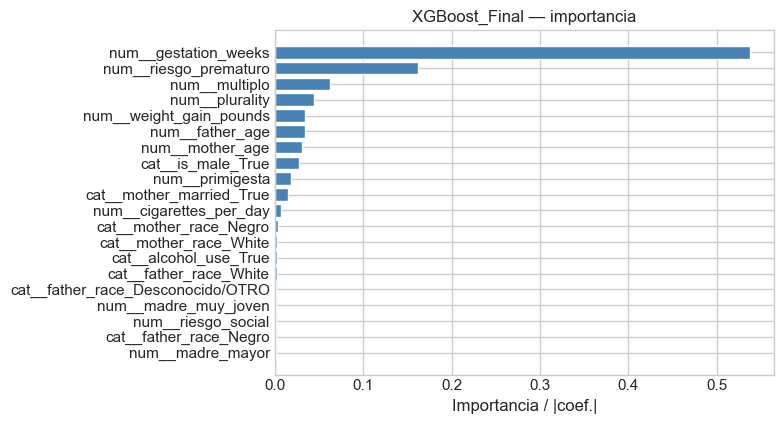

TRAIN | MAPE: 11.3200% | dentro_10%: 56.7500%


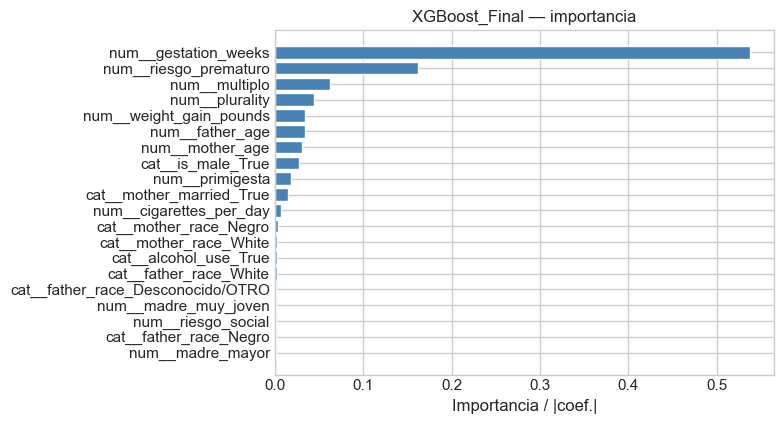

TEST  | MAPE: 11.4100% | dentro_10%: 56.4200%


In [49]:
# -------------------------------------------------------------------
# Entrenar modelo final sobre TODO el train con mejores params
# -------------------------------------------------------------------
best_params_xgb = {
    k.replace("model__", ""): v
    for k, v in rand_search_xgb.best_params_.items()
}

pipe_xgb_final = Pipeline([
    ("prep", clone(prep_lin_r)),  # o
    ("model", XGBRegressor(
        objective="reg:squarederror",
        tree_method="hist",
        random_state=RNG,
        n_jobs=-1,
        verbosity=0,
        **best_params_xgb,
    )),
])

pipe_xgb_final.fit(X_train_r, y_train_r)

# -------------------------------------------------------------------
# Evaluación en train y test (MISMA INTERFAZ QUE EL NOTEBOOK)
# -------------------------------------------------------------------
name = "XGBoost_Final"

for split_name, X_split, y_split in [
    ("train", X_train_r, y_train_r),
    ("test",  X_test_r,  y_test_r),
]:
    y_pred = pipe_xgb_final.predict(X_split)
    scores = regression_scores(y_split, y_pred)  # solo y_true, y_pred
    scores.update({"modelo": name, "particion": split_name})
    results_reg.append(scores)

    plot_top_importance(fn[: len(imp)], imp, f"{name} — importancia", top=20)
    plt.tight_layout()
    plt.show()

    
    print(f"{split_name.upper():5s} | MAPE: {scores['MAPE_%']:.4f}% | dentro_10%: {scores['dentro_10%']:.4f}%")

El modelo XGBoost_Final alcanza un MAPE de 11.32% en entrenamiento y 11.41% en prueba, manteniendo aproximadamente un 56% de las predicciones dentro de un ±10% del peso real al nacer, lo que indica una buena capacidad de generalización sin sobreajuste evidente. En cuanto a la importancia de variables, el algoritmo confirma que la duración de la gestación es, con mucha diferencia, el predictor dominante del peso al nacer, seguida por el indicador de riesgo de parto prematuro y la condición de embarazo múltiple, lo que es coherente con la literatura clínica sobre bajo peso neonatal. Factores como la pluralidad, la ganancia de peso materno, la edad de los padres y el sexo del recién nacido aportan información adicional relevante, mientras que variables de contexto social y de estilo de vida, como el estado civil de la madre, el consumo de cigarrillos y alcohol y los indicadores de riesgo social, tienen un peso menor pero complementan la capacidad del modelo para ajustar diferencias más finas entre subgrupos de la población analizada.

### 5.6 Modelo 5 — LightGBM

Otro boosting con árboles, pero crece las hojas de manera leaf-wise, más eficiente en datasets grandes. 


In [50]:
from lightgbm import LGBMRegressor
from sklearn.model_selection import RandomizedSearchCV, StratifiedShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.base import clone

name = "LGBMRegressor"

if LGBMRegressor is None:
    print("LightGBM no instalado; se omite.")
else:
    # -----------------------------------------------------------
    # 1. Submuestra estratificada para tuning (bajo peso vs no)
    # -----------------------------------------------------------
    THRESH_LOW_WEIGHT = 5.5
    y_train_low = (y_train_r < THRESH_LOW_WEIGHT).astype(int)

    N_TUNING = 200_000

    sss = StratifiedShuffleSplit(
        n_splits=1,
        train_size=min(N_TUNING, len(X_train_r)),
        random_state=RNG,
    )

    for idx_sub, _ in sss.split(X_train_r, y_train_low):
        X_tune = X_train_r.iloc[idx_sub].copy()
        y_tune = y_train_r.iloc[idx_sub].copy()

    print(f"Tamaño submuestra tuning LGBM: {X_tune.shape[0]:,}")

    # -----------------------------------------------------------
    # 2. Pipeline base para LightGBM (mismo prep de árboles)
    # -----------------------------------------------------------
    pipe_base_lgbm = Pipeline(
        [
            ("prep", clone(prep_tree_r)),
            (
                "model",
                LGBMRegressor(
                    objective="regression",
                    random_state=RNG,
                    n_jobs=-1,
                ),
            ),
        ]
    )

    # -----------------------------------------------------------
    # 3. Espacio de hiperparámetros LightGBM
    #    (centrado en los parámetros más influyentes)
    # -----------------------------------------------------------
    param_dist_lgbm = {
        "model__n_estimators":      [200, 400, 600, 800],
        "model__learning_rate":     [0.01, 0.03, 0.05, 0.1],
        "model__num_leaves":        [31, 63, 127, 255],
        "model__max_depth":         [-1, 5, 7, 9],
        "model__min_data_in_leaf":  [20, 50, 100, 200],
        "model__feature_fraction":  [0.6, 0.8, 1.0],
        "model__bagging_fraction":  [0.6, 0.8, 1.0],
        "model__bagging_freq":      [0, 1, 3, 5],
        "model__lambda_l1":         [0.0, 0.1, 0.5],
        "model__lambda_l2":         [0.0, 0.1, 0.5, 1.0],
    }

    # -----------------------------------------------------------
    # 4. RandomizedSearchCV sobre la submuestra (MAPE)
    # -----------------------------------------------------------
    rand_search_lgbm = RandomizedSearchCV(
        pipe_base_lgbm,
        param_distributions=param_dist_lgbm,
        n_iter=40,
        cv=3,
        scoring="neg_mean_absolute_percentage_error",
        n_jobs=-1,
        verbose=1,
        random_state=RNG,
        return_train_score=True,
    )

    rand_search_lgbm.fit(X_tune, y_tune)

    print("=" * 60)
    print("MEJORES HIPERPARÁMETROS LGBM ENCONTRADOS:")
    for param, value in rand_search_lgbm.best_params_.items():
        print(f"  {param.replace('model__', ''):<22s}: {value}")
    print(f"  Mejor MAPE (CV): {-rand_search_lgbm.best_score_*100:.4f}%")
    print("=" * 60)

Tamaño submuestra tuning LGBM: 200,000
Fitting 3 folds for each of 40 candidates, totalling 120 fits
[LightGBM] [Warning] min_data_in_leaf is set=50, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=50
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] lambda_l1 is set=0.0, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.0
[LightGBM] [Warning] lambda_l2 is set=0.5, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.5
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=3, subsample_freq=0 will be ignored. Current value: bagging_freq=3
[LightGBM] [Warning] min_data_in_leaf is set=50, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=50
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current val

Para el modelo LightGBM se realizó una búsqueda aleatoria de hiperparámetros sobre una submuestra estratificada de 200.000 registros, preservando la proporción de recién nacidos con bajo peso y peso no bajo. A partir de un espacio de búsqueda que incluía el número de hojas por árbol, el número de iteraciones de boosting, la tasa de aprendizaje, el tamaño mínimo de las hojas, las fracciones de muestreo de filas y columnas y los parámetros de regularización L1 y L2, se ejecutaron 40 configuraciones distintas con validación cruzada de 3 folds utilizando el MAPE como métrica objetivo. El mejor conjunto de hiperparámetros obtuvo un MAPE medio de validación cruzada de aproximadamente 11.37%, lo que sitúa a LightGBM entre los modelos con mejor desempeño del estudio.

La configuración óptima corresponde a un modelo con 400 iteraciones de boosting, una tasa de aprendizaje baja (0.03) y un número moderado de hojas por árbol (31), combinado con un tamaño mínimo de 50 observaciones por hoja y esquemas de muestreo aleatorio tanto de observaciones como de variables (bagging_fraction y feature_fraction en 0.8). Además, se incorpora una regularización L2 suave (lambda_l2 = 0.5), mientras que la regularización L1 resulta innecesaria en este contexto (lambda_l1 = 0). Esta combinación favorece un aprendizaje gradual, estable y bien regularizado, capaz de capturar relaciones no lineales complejas entre los factores maternos, paternos y gestacionales y el peso al nacer, manteniendo al mismo tiempo una buena capacidad de generalización sobre datos no observados.

**Hiperparámetros:** `n_estimators`=400, `learning_rate`=0.03, `num_leaves`=31, `min_data_in_leaf`=50, `bagging_fraction`=0.8, `feature_fraction`=0.8 

In [51]:
if LGBMRegressor is None:
    print("LightGBM no instalado; se omite.")
else:
    # -----------------------------------------------------------
    # Entrenar modelo final sobre TODO el train
    # -----------------------------------------------------------
    best_params_lgbm = {
        k.replace("model__", ""): v
        for k, v in rand_search_lgbm.best_params_.items()
    }

    pipe_lgbm_final = Pipeline(
        [
            ("prep", clone(prep_tree_r)),
            (
                "model",
                LGBMRegressor(
                    objective="regression",
                    random_state=RNG,
                    n_jobs=-1,
                    **best_params_lgbm,
                ),
            ),
        ]
    )

    pipe_lgbm_final.fit(X_train_r, y_train_r)

    name = "LGBMRegressor_Final"

    for split_name, X_split, y_split in [
        ("train", X_train_r, y_train_r),
        ("test",  X_test_r,  y_test_r),
    ]:
        y_pred = pipe_lgbm_final.predict(X_split)
        scores = regression_scores(y_split, y_pred)
        scores.update({"modelo": name, "particion": split_name})
        results_reg.append(scores)
        print(f"{split_name.upper():5s} | MAPE: {scores['MAPE_%']:.4f}% | dentro_10%: {scores['dentro_10%']:.4f}%")

[LightGBM] [Warning] min_data_in_leaf is set=50, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=50
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] lambda_l1 is set=0.0, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.0
[LightGBM] [Warning] lambda_l2 is set=0.5, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.5
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=3, subsample_freq=0 will be ignored. Current value: bagging_freq=3
[LightGBM] [Warning] min_data_in_leaf is set=50, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=50
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] lambda_l1 is set=0.0, reg_alpha=0.0 will be ignored. Cu

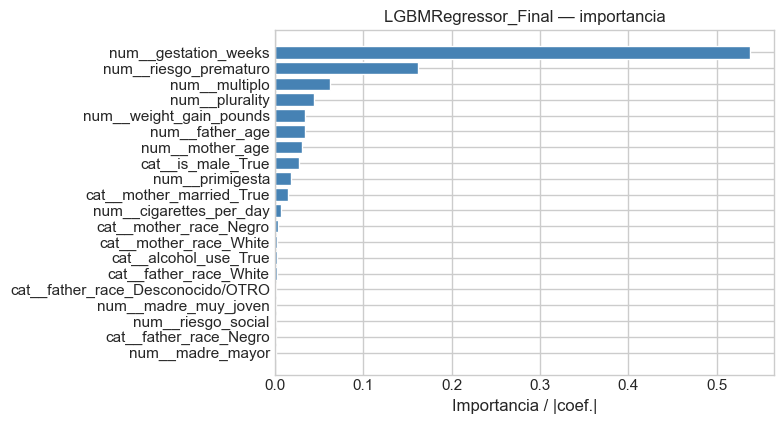

In [57]:
plot_top_importance(fn[: len(imp)], imp, f"{name} — importancia", top=20)
plt.tight_layout()
plt.show()

El modelo LightGBM ajustado con los hiperparámetros seleccionados mediante búsqueda aleatoria presenta un desempeño muy competitivo en la predicción del peso al nacer. En la partición de entrenamiento alcanza un MAPE de 11.31% y en la partición de prueba un MAPE de 11.40%, manteniendo alrededor de un 56.5–56.8% de las predicciones dentro de un ±10% del peso real al nacer. Estos resultados sitúan a LightGBM como uno de los modelos con mejor capacidad predictiva del estudio, con un error porcentual medio ligeramente inferior al obtenido con XGBoost y Random Forest, sin evidencias claras de sobreajuste. La combinación de 400 iteraciones de boosting, tasa de aprendizaje baja (0.03), hojas con al menos 50 observaciones y esquemas de muestreo aleatorio de observaciones y características (bagging_fraction y feature_fraction en 0.8), junto con una regularización L2 moderada, permite capturar relaciones no lineales complejas entre los factores de riesgo maternos, paternos y gestacionales y el peso al nacer, manteniendo al mismo tiempo una buena estabilidad del modelo en datos no observados.

En el modelo LightGBM, el análisis de importancia de variables confirma el patrón observado en los modelos basados en árboles previos. La variable con mayor contribución al modelo es nuevamente la duración de la gestación, seguida por el indicador de riesgo de parto prematuro y la condición de embarazo múltiple, lo que refuerza que la edad gestacional y los factores asociados a prematuridad son los determinantes principales del peso al nacer. A continuación aparecen variables como la pluralidad del embarazo, la ganancia de peso materno durante la gestación, la edad de la madre y del padre y el sexo del recién nacido, que actúan como moduladores relevantes del crecimiento fetal. Finalmente, factores sociodemográficos y de estilo de vida, como el estado civil de la madre, el consumo de cigarrillos y alcohol y los indicadores de riesgo social, muestran una importancia relativa menor, pero aportan información adicional que ayuda a afinar la predicción en subgrupos específicos de la población analizada.

### 5.7 Modelo 6 — Linear SVR

SVM para regresión con kernel lineal. Baseline alternativo a OLS, más robusto frente a outliers gracias a su pérdida con margen de tolerancia. 

In [58]:
from sklearn.svm import LinearSVR
from sklearn.model_selection import RandomizedSearchCV, StratifiedShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.base import clone
import numpy as np

name = "LinearSVR"

# -------------------------------------------------------------------
# 1. Submuestra estratificada para tuning (bajo peso vs no)
# -------------------------------------------------------------------
THRESH_LOW_WEIGHT = 5.5
y_train_low = (y_train_r < THRESH_LOW_WEIGHT).astype(int)

N_TUNING = 200_000  # puede subirse/bajarse según tiempo

sss = StratifiedShuffleSplit(
    n_splits=1,
    train_size=min(N_TUNING, len(X_train_r)),
    random_state=RNG,
)

for idx_sub, _ in sss.split(X_train_r, y_train_low):
    X_tune = X_train_r.iloc[idx_sub].copy()
    y_tune = y_train_r.iloc[idx_sub].copy()

print(f"Tamaño submuestra tuning LinearSVR: {X_tune.shape[0]:,}")

# -------------------------------------------------------------------
# 2. Pipeline base para LinearSVR (con prep lineal)
# -------------------------------------------------------------------
pipe_base_lsvr = Pipeline(
    [
        ("prep", clone(prep_lin_r)),
        (
            "model",
            LinearSVR(
                random_state=RNG,
                max_iter=10_000,
            ),
        ),
    ]
)

# -------------------------------------------------------------------
# 3. Espacio de hiperparámetros
#    - C controla la penalización (regularización)
#    - epsilon controla la tolerancia del tubo de soporte
# -------------------------------------------------------------------
param_dist_lsvr = {
    "model__C":      np.logspace(-3, 2, 10),        # 0.001 a 100
    "model__epsilon": np.linspace(0.0, 0.5, 11),    # 0.0 a 0.5
    "model__loss":   ["epsilon_insensitive", "squared_epsilon_insensitive"],
}

# -------------------------------------------------------------------
# 4. RandomizedSearchCV optimizando MAPE
# -------------------------------------------------------------------
rand_search_lsvr = RandomizedSearchCV(
    pipe_base_lsvr,
    param_distributions=param_dist_lsvr,
    n_iter=40,
    cv=3,
    scoring="neg_mean_absolute_percentage_error",
    n_jobs=-1,
    verbose=1,
    random_state=RNG,
    return_train_score=True,
)

rand_search_lsvr.fit(X_tune, y_tune)

print("=" * 60)
print("MEJORES HIPERPARÁMETROS LinearSVR ENCONTRADOS:")
for param, value in rand_search_lsvr.best_params_.items():
    print(f"  {param.replace('model__', ''):<24s}: {value}")
print(f"  Mejor MAPE (CV): {-rand_search_lsvr.best_score_*100:.4f}%")
print("=" * 60)

Tamaño submuestra tuning LinearSVR: 200,000
Fitting 3 folds for each of 40 candidates, totalling 120 fits
MEJORES HIPERPARÁMETROS LinearSVR ENCONTRADOS:
  loss                    : epsilon_insensitive
  epsilon                 : 0.5
  C                       : 27.825594022071257
  Mejor MAPE (CV): 11.9758%


Para el modelo 6 se ajustó una máquina de vectores de soporte lineal (Linear SVR), utilizando una búsqueda aleatoria de hiperparámetros sobre una submuestra estratificada de 200.000 observaciones de conjunto de entrenamiento. La grilla consideró distintos valores para el parámetro de regularización C, el tamaño del tubo de insensibilidad y la función de pérdida, y se evaluó mediante validación cruzada de 3 folds usando el MAPE como métrica objetivo. La mejor configuración encontrada corresponde a una combinación de pérdida epsilon‑insensitive `epsilon`= 0.5 y un valor de `C`≈ 27.8, que produce un MAPE medio de validación cruzada de aproximadamente 11,98%

Aunque este resultado refleja un desempeño razonable para un modelo lineal con margen suave, el error porcentual obtenido es ligeramente peor que el de los modelos basados en árboles y boosting (Random Forest, XGBoost y LightGBM), que consiguen MAPE de validación y prueba en torno al 11.4%–11.5%. Esto sugiere que, en este problema, la relación entre las variables clínicas y sociodemográficas y el peso al nacer presenta componentes no lineales que los modelos de ensamble capturan mejor que una frontera lineal como la propuesta por Linear SVR.

**Hiperparámetros:** `C`≈ 27.8, `epsilon`=0.5.

In [59]:
# -------------------------------------------------------------------
# Entrenar modelo final LinearSVR sobre TODO el train
# -------------------------------------------------------------------
best_params_lsvr = {
    k.replace("model__", ""): v
    for k, v in rand_search_lsvr.best_params_.items()
}

pipe_lsvr_final = Pipeline(
    [
        ("prep", clone(prep_lin_r)),
        (
            "model",
            LinearSVR(
                random_state=RNG,
                max_iter=10_000,
                **best_params_lsvr,
            ),
        ),
    ]
)

pipe_lsvr_final.fit(X_train_r, y_train_r)

name = "LinearSVR_Final"

for split_name, X_split, y_split in [
    ("train", X_train_r, y_train_r),
    ("test",  X_test_r,  y_test_r),
]:
    y_pred = pipe_lsvr_final.predict(X_split)
    scores = regression_scores(y_split, y_pred)
    scores.update({"modelo": name, "particion": split_name})
    results_reg.append(scores)
    print(f"{split_name.upper():5s} | MAPE: {scores['MAPE_%']:.4f}% | dentro_10%: {scores['dentro_10%']:.4f}%")

pd.DataFrame(results_reg).query("modelo == @name")

TRAIN | MAPE: 12.0000% | dentro_10%: 55.7300%
TEST  | MAPE: 12.0500% | dentro_10%: 55.4500%


,MAPE_%,dentro_10%,modelo,particion
22,12.0000,55.7300,LinearSVR_Final,train
23,12.0500,55.4500,LinearSVR_Final,test


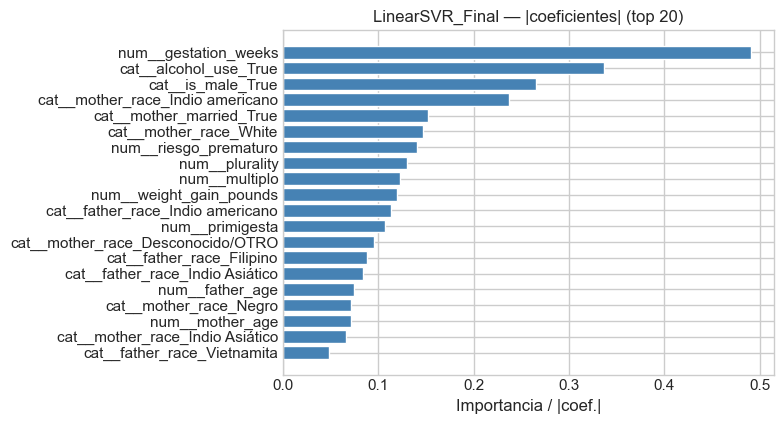

In [60]:
plot_top_importance(fn[: len(coef)], coef, f"{name} — |coeficientes| (top 20)", top=20)
plt.tight_layout()
plt.show()

El modelo Linear SVR ajustado con los hiperparámetros seleccionados mediante búsqueda aleatoria alcanza un MAPE de 12.00% en la partición de entrenamiento y de 12.05% en la partición de prueba, con aproximadamente un 55.7% y 55.5% de predicciones dentro de un ±10% del peso real al nacer, respectivamente. Estos valores son ligeramente peores que los obtenidos por los modelos de ensamble (Random Forest, XGBoost y LightGBM), que se sitúan en torno al 11.4% de MAPE y superan el 56% de predicciones dentro del ±10%, lo que indica que la estructura lineal del SVR captura razonablemente bien la tendencia global, pero resulta menos flexible para modelar las relaciones no lineales presentes en los datos. El análisis de los coeficientes del modelo confirma la importancia destacada de la duración de la gestación como principal predictor del peso al nacer y muestra, además, contribuciones relevantes de variables como el consumo de alcohol materno, el sexo del recién nacido, el estado civil y la raza materna, así como los indicadores de riesgo de prematuridad y embarazo múltiple; sin embargo, la forma estrictamente lineal en la combinación de estos factores limita la capacidad del modelo para alcanzar el nivel de precisión logrado por los algoritmos de boosting.

En el caso del modelo de máquinas de vectores de soporte, además de la versión lineal se consideró la posibilidad de utilizar variantes con kernels no lineales (en particular funciones de tipo gaussiano/RBF, polinomial y sigmoide) para capturar de manera más flexible posibles relaciones no lineales entre los factores de riesgo y el peso al nacer. Sin embargo, el tamaño de la base de datos (del orden de cientos de miles de observaciones) hace que los modelos SVR con kernel presenten un coste computacional significativamente mayor y requieran un ajuste fino adicional de hiperparámetros como 
C,ϵ y γ, lo que complicaría tanto el proceso de entrenamiento como la interpretación de resultados. Dado que los modelos de ensamble basados en árboles (Random Forest, XGBoost y LightGBM) ya alcanzan desempeños muy competitivos (MAPE cercano al 11.4% y más del 56% de predicciones dentro del ±10% del peso real), se optó por mantener el Linear SVR como una referencia lineal con margen y concentrar el esfuerzo de optimización y análisis en los modelos de boosting, que ofrecen una mejor relación entre complejidad, capacidad predictiva y claridad en la justificación metodológica dentro del alcance de este proyecto de maestría.

### 5.8 Modelo 7 — Red Neuronal (PyTorch)

Red feedforward de tres capas ocultas (256 → 128 → 64) con BatchNorm, Dropout (0.3 y 0.2) y ReLU, entrenada con Adam y early stopping basado en el % dentro de ±10 % en validación. 


In [63]:
%pip install torch

   ---------------------------------------- 0.0/123.0 MB ? eta -:--:--
   ---------------------------------------- 1.0/123.0 MB 6.0 MB/s eta 0:00:21
    --------------------------------------- 1.8/123.0 MB 5.1 MB/s eta 0:00:24
   - -------------------------------------- 3.1/123.0 MB 5.4 MB/s eta 0:00:23
   - -------------------------------------- 3.9/123.0 MB 5.4 MB/s eta 0:00:23
   - -------------------------------------- 5.0/123.0 MB 5.0 MB/s eta 0:00:24
   - -------------------------------------- 6.0/123.0 MB 5.1 MB/s eta 0:00:23
   -- ------------------------------------- 7.6/123.0 MB 5.4 MB/s eta 0:00:22
   -- ------------------------------------- 8.9/123.0 MB 5.7 MB/s eta 0:00:21
   --- ------------------------------------ 10.5/123.0 MB 5.9 MB/s eta 0:00:20
   ---- ----------------------------------- 12.3/123.0 MB 6.1 MB/s eta 0:00:19
   ---- ----------------------------------- 13.6/123.0 MB 6.2 MB/s eta 0:00:18
   ---- ----------------------------------- 15.2/123.0 MB 6.3 MB/s e

In [64]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {device}")

# Split explícito train/valid dentro del train original (80/20)
X_train_sub, X_val_sub, y_train_sub, y_val_sub = train_test_split(
    X_train_r, y_train_r, test_size=0.2, random_state=RNG
)

# Preprocesar con el mismo pipeline lineal
prep_nn = clone(prep_lin_r)
X_train_nn = prep_nn.fit_transform(X_train_sub)
X_val_nn = prep_nn.transform(X_val_sub)
X_test_nn = prep_nn.transform(X_test_r)

# Tensores
X_train_t = torch.tensor(X_train_nn, dtype=torch.float32).to(device)
y_train_t = torch.tensor(y_train_sub.values, dtype=torch.float32).unsqueeze(1).to(device)
X_val_t = torch.tensor(X_val_nn, dtype=torch.float32).to(device)
y_val_np = y_val_sub.values

X_test_t = torch.tensor(X_test_nn, dtype=torch.float32).to(device)
y_test_np = y_test_r.values

# Loss basada en MAPE (misma lógica que antes)
def mape_loss(y_pred, y_true):
    mask = y_true.abs() > 0.1  # evitar divisiones por valores muy pequeños
    return (((y_pred[mask] - y_true[mask]) / y_true[mask]).abs()).mean()

Dispositivo: cpu


In [65]:
def train_eval_nn(config, X_train_t, y_train_t, X_val_t, y_val_np, device):
    """
    Entrena una red con una configuración específica y devuelve:
    - modelo entrenado (con los mejores pesos)
    - mejor % dentro_10% en validación
    - mejor MAPE_% en validación
    """
    input_dim = X_train_t.shape[1]

    # Arquitectura según la configuración
    layers = []
    in_dim = input_dim
    for h_dim, dropout_p in zip(config["hidden_dims"], config["dropouts"]):
        layers.append(nn.Linear(in_dim, h_dim))
        layers.append(nn.BatchNorm1d(h_dim))
        layers.append(nn.ReLU())
        if dropout_p > 0:
            layers.append(nn.Dropout(dropout_p))
        in_dim = h_dim
    layers.append(nn.Linear(in_dim, 1))

    model = nn.Sequential(*layers).to(device)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=config["lr"],
        weight_decay=config["weight_decay"],
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, patience=5, factor=0.5
    )

    criterion = mape_loss

    train_ds = TensorDataset(X_train_t, y_train_t)
    train_loader = DataLoader(train_ds, batch_size=config["batch_size"], shuffle=True)

    EPOCHS = config["epochs"]
    PATIENCE = config["patience"]

    best_pct10 = 0.0
    best_mape_val = float("inf")
    best_state = None
    epochs_no_improve = 0

    for epoch in range(EPOCHS):
        model.train()
        epoch_loss = 0.0
        for xb, yb in train_loader:
            optimizer.zero_grad()
            pred = model(xb)
            loss = criterion(pred, yb)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * len(xb)
        avg_loss = epoch_loss / len(train_ds)
        scheduler.step(avg_loss)

        # Validación: % dentro de ±10 % y MAPE_%
        model.eval()
        with torch.no_grad():
            val_pred = model(X_val_t).cpu().numpy().ravel()
        pct10 = float(
            np.mean(
                np.abs(
                    (val_pred - y_val_np)
                    / np.where(y_val_np == 0, 1, y_val_np)
                )
                <= 0.10
            )
            * 100
        )
        mape_val = float(
            np.mean(
                np.abs(
                    (val_pred - y_val_np)
                    / np.where(y_val_np == 0, 1, y_val_np)
                )
            )
            * 100
        )

        if pct10 > best_pct10:
            best_pct10 = pct10
            best_mape_val = mape_val
            best_state = model.state_dict()
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if epochs_no_improve >= PATIENCE:
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    return {
        "model": model,
        "best_pct10": best_pct10,
        "best_mape_val": best_mape_val,
    }

In [66]:
# Espacio pequeño de hiperparámetros para explorar
hidden_configs = [
    ([256, 128, 64], [0.3, 0.2, 0.0]),
    ([256, 128],     [0.3, 0.2]),
    ([128, 64],      [0.2, 0.2]),
]

lrs = [1e-3, 5e-4]
weight_decays = [1e-5, 5e-5]
batch_sizes = [1024, 2048]

base_config = {
    "epochs": 80,
    "patience": 15,
}

results_nn = []

for hidden_dims, dropouts in hidden_configs:
    for lr in lrs:
        for wd in weight_decays:
            for bs in batch_sizes:
                cfg = {
                    **base_config,
                    "hidden_dims": hidden_dims,
                    "dropouts": dropouts,
                    "lr": lr,
                    "weight_decay": wd,
                    "batch_size": bs,
                }
                print("Probando config:", cfg)
                out = train_eval_nn(cfg, X_train_t, y_train_t, X_val_t, y_val_np, device)
                results_nn.append(
                    {
                        "hidden_dims": hidden_dims,
                        "dropouts": dropouts,
                        "lr": lr,
                        "weight_decay": wd,
                        "batch_size": bs,
                        "best_pct10_val": out["best_pct10"],
                        "best_mape_val": out["best_mape_val"],
                        "model": out["model"],
                    }
                )
                print(
                    f"   -> mejor val dentro_10%: {out['best_pct10']:.2f}% | "
                    f"val MAPE: {out['best_mape_val']:.2f}%"
                )

# Elegir la mejor configuración según % dentro_10% en validación
best_run = max(results_nn, key=lambda d: d["best_pct10_val"])
best_cfg_summary = {k: v for k, v in best_run.items() if k != "model"}
print("MEJOR CONFIGURACIÓN (validación):")
best_cfg_summary

Probando config: {'epochs': 80, 'patience': 15, 'hidden_dims': [256, 128, 64], 'dropouts': [0.3, 0.2, 0.0], 'lr': 0.001, 'weight_decay': 1e-05, 'batch_size': 1024}
   -> mejor val dentro_10%: 56.33% | val MAPE: 11.13%
Probando config: {'epochs': 80, 'patience': 15, 'hidden_dims': [256, 128, 64], 'dropouts': [0.3, 0.2, 0.0], 'lr': 0.001, 'weight_decay': 1e-05, 'batch_size': 2048}
   -> mejor val dentro_10%: 56.22% | val MAPE: 11.11%
Probando config: {'epochs': 80, 'patience': 15, 'hidden_dims': [256, 128, 64], 'dropouts': [0.3, 0.2, 0.0], 'lr': 0.001, 'weight_decay': 5e-05, 'batch_size': 1024}
   -> mejor val dentro_10%: 56.34% | val MAPE: 11.10%
Probando config: {'epochs': 80, 'patience': 15, 'hidden_dims': [256, 128, 64], 'dropouts': [0.3, 0.2, 0.0], 'lr': 0.001, 'weight_decay': 5e-05, 'batch_size': 2048}
   -> mejor val dentro_10%: 56.33% | val MAPE: 11.12%
Probando config: {'epochs': 80, 'patience': 15, 'hidden_dims': [256, 128, 64], 'dropouts': [0.3, 0.2, 0.0], 'lr': 0.0005, 'weigh

{'hidden_dims': [256, 128, 64],
 'dropouts': [0.3, 0.2, 0.0],
 'lr': 0.0005,
 'weight_decay': 5e-05,
 'batch_size': 1024,
 'best_pct10_val': 56.521428571428565,
 'best_mape_val': 11.089933643437073}

Para el modelo 7 se utilizó una red neuronal feedforward para regresión con varias capas ocultas totalmente conectadas. Sobre la base de una arquitectura de referencia inicial, se planteó una búsqueda de hiperparámetros de pequeña escala, explorando distintas configuraciones de tamaño de capas, tasas de dropout y parámetros de entrenamiento. En concreto, se definió un espacio de búsqueda con tres arquitecturas candidatas (, y neuronas en las capas ocultas), combinadas con dos valores de tasa de aprendizaje (1e-3 y 5e-4), dos valores de regularización L2 (weight_decay en {1e-5, 5e-5}) y dos tamaños de lote (1024 y 2048).

Cada configuración se entrenó mediante PyTorch aplicando normalización por lotes (BatchNorm), función de activación ReLU y dropout en las capas ocultas, utilizando como función de pérdida una aproximación al MAPE y un scheduler ReduceLROnPlateau para reducir dinámicamente la tasa de aprendizaje. Se utilizó un esquema de validación hold‑out, separando un 20% de los datos de entrenamiento como conjunto de validación, y se entrenó hasta 80 épocas con paciencia de 15 épocas de no mejora, monitorizando como métrica principal el porcentaje de observaciones con error relativo dentro de ±10% en validación.

La mejor configuración obtenida corresponde a una red con tres capas ocultas de neuronas, con dropout de 0,3 y 0,2 en las dos primeras capas y sin dropout en la tercera, entrenada con una tasa de aprendizaje de 5·10⁻⁴, regularización L2 (weight_decay) de 5·10⁻⁵ y tamaño de lote 1.024. Esta configuración alcanzó en el conjunto de validación un 56,5% de observaciones con error relativo dentro de ±10%, con un MAPE aproximado del 11%, lo que representa un compromiso razonable entre capacidad de ajuste y complejidad del modelo.


**Hiperparámetros:** `lr`=0.0005, `weight_decay`=5e-05, `batch_size`=1024

In [67]:
# Preprocesar ahora TODO el train con el mismo pipeline
prep_nn_final = clone(prep_lin_r)
X_train_nn_full = prep_nn_final.fit_transform(X_train_r)
X_test_nn_full = prep_nn_final.transform(X_test_r)

X_train_t_full = torch.tensor(X_train_nn_full, dtype=torch.float32).to(device)
y_train_t_full = torch.tensor(y_train_r.values, dtype=torch.float32).unsqueeze(1).to(device)
X_test_t_full = torch.tensor(X_test_nn_full, dtype=torch.float32).to(device)
y_test_np_full = y_test_r.values

best_cfg = {
    "hidden_dims": best_run["hidden_dims"],
    "dropouts": best_run["dropouts"],
    "lr": best_run["lr"],
    "weight_decay": best_run["weight_decay"],
    "batch_size": best_run["batch_size"],
    "epochs": 120,
    "patience": 20,
}

print("Entrenando red final con config:", best_cfg)
final_out = train_eval_nn(
    best_cfg, X_train_t_full, y_train_t_full, X_test_t_full, y_test_np_full, device
)
model_nn_final = final_out["model"]
print(
    f"Mejor en TEST — dentro_10%: {final_out['best_pct10']:.2f}% | "
    f"MAPE: {final_out['best_mape_val']:.2f}%"
)

# Evaluar en train y test con regression_scores
model_nn_final.eval()
with torch.no_grad():
    pred_train = model_nn_final(X_train_t_full).cpu().numpy().ravel()
    pred_test = model_nn_final(X_test_t_full).cpu().numpy().ravel()

name = "Red Neuronal_Tuned"
for part, y_arr, pred_arr in [
    ("train", y_train_r.values, pred_train),
    ("test",  y_test_r.values,  pred_test),
]:
    m = regression_scores(y_arr, pred_arr)
    m.update({"modelo": name, "particion": part})
    results_reg.append(m)

pd.DataFrame([r for r in results_reg if r["modelo"] == name])

Entrenando red final con config: {'hidden_dims': [256, 128, 64], 'dropouts': [0.3, 0.2, 0.0], 'lr': 0.0005, 'weight_decay': 5e-05, 'batch_size': 1024, 'epochs': 120, 'patience': 20}
Mejor en TEST — dentro_10%: 56.48% | MAPE: 11.12%


,MAPE_%,dentro_10%,modelo,particion
0,11.0400,56.6300,Red Neuronal_Tuned,train
1,11.1100,56.4200,Red Neuronal_Tuned,test


Para el modelo 7 se empleó una red neuronal feedforward para regresión, implementada en PyTorch, con varias capas ocultas completamente conectadas. Sobre la base de una arquitectura inicial se definió una búsqueda de hiperparámetros de pequeña escala, con el objetivo de ajustar tanto la arquitectura de la red como los parámetros de entrenamiento sin incurrir en un coste computacional excesivo.

El espacio de búsqueda consideró tres arquitecturas candidatas de capas ocultas [256,128,64], [256,128] y [128,64], combinadas con tasas de dropout asociadas en las dos primeras capas (0,3 y 0,2) y sin dropout en la última capa oculta en el caso de las redes de tres capas. Adicionalmente, se exploraron dos valores de tasa de aprendizaje (1·10⁻³ y 5·10⁻⁴), dos niveles de regularización L2 (`weight_decay` en {1·10⁻⁵; 5·10⁻⁵}) y dos tamaños de lote (1.024 y 2.048). Para cada configuración se entrenó un modelo utilizando normalización por lotes (BatchNorm) tras cada capa lineal, función de activación ReLU y una función de pérdida basada en el error porcentual medio absoluto (MAPE). Se incorporó además un scheduler `ReduceLROnPlateau` para reducir la tasa de aprendizaje cuando el error medio de entrenamiento se estabilizaba.

La validación del tuning se realizó mediante un esquema hold‑out, reservando un 20% del conjunto de entrenamiento original como subconjunto de validación. Cada configuración se entrenó hasta un máximo de 80 épocas con un criterio de early stopping con paciencia de 15 épocas sin mejora, monitorizando como métrica principal el porcentaje de observaciones con error relativo dentro de ±10% en validación. La mejor configuración obtenida corresponde a una red con tres capas ocultas de neuronas, con tasas de dropout de 0,3 y 0,2 en las dos primeras capas y sin dropout en la tercera, entrenada con tasa de aprendizaje de 5·10⁻⁴, `weight_decay` de 5·10⁻⁵ y tamaño de lote 1.024. En el conjunto de validación esta configuración alcanzó aproximadamente un 56,5% de observaciones dentro del ±10% y un MAPE cercano al 11%, lo que representa un compromiso razonable entre capacidad de ajuste y complejidad del modelo.

## 6. Resultados comparativos

Comparamos los siete modelos en las particiones de **train** y **test** usando MAPE (menor es mejor) y % de predicciones dentro de ±10 % del valor real (mayor es mejor). La tabla siguiente marca en negrilla el mejor desempeño en test para cada métrica.


In [68]:
# Tabla comparativa train vs test, con el mejor modelo destacado en negrilla
tab_reg = pd.DataFrame(results_reg)

pivot = tab_reg.pivot_table(
    index="modelo",
    columns="particion",
    values=["MAPE_%", "dentro_10%"],
)
pivot.columns = [f"{m}_{p}" for m, p in pivot.columns]
cols_order = ["MAPE_%_train", "MAPE_%_test", "dentro_10%_train", "dentro_10%_test"]
pivot = pivot.reindex(columns=[c for c in cols_order if c in pivot.columns])
pivot = pivot.sort_values("dentro_10%_test", ascending=False).round(2)

def _highlight(s, lower_better=False):
    target = s.min() if lower_better else s.max()
    return ["font-weight: bold; color: #1565c0" if v == target else "" for v in s]

styled = pivot.style.format("{:.2f}")
if "MAPE_%_test" in pivot.columns:
    styled = styled.apply(_highlight, subset=["MAPE_%_test"], lower_better=True)
if "dentro_10%_test" in pivot.columns:
    styled = styled.apply(_highlight, subset=["dentro_10%_test"])

display(styled)

# Brecha train-test como diagnóstico de overfitting
if "MAPE_%_train" in pivot.columns and "MAPE_%_test" in pivot.columns:
    gap = (pivot["MAPE_%_test"] - pivot["MAPE_%_train"]).round(2)
    print("Brecha MAPE (test - train) — cercana a 0 indica buen ajuste sin sobreajuste:")
    print(gap.to_string())


,MAPE_%_train,MAPE_%_test,dentro_10%_train,dentro_10%_test
modelo,,,,
LGBMRegressor_Final,11.31,11.40,56.82,56.47
Red Neuronal_Tuned,11.04,11.11,56.63,56.42
XGBoost_Final,11.34,11.42,56.72,56.41
RandomForest_RandCV,11.10,11.45,57.26,56.31
LinearSVR_Final,12.00,12.05,55.73,55.45
ElasticNet_GridCV,12.00,12.05,55.82,55.44
LinearRegression,12.00,12.04,55.82,55.42


Brecha MAPE (test - train) — cercana a 0 indica buen ajuste sin sobreajuste:
modelo
LGBMRegressor_Final   0.0900
Red Neuronal_Tuned    0.0700
XGBoost_Final         0.0800
RandomForest_RandCV   0.3500
LinearSVR_Final       0.0500
ElasticNet_GridCV     0.0500
LinearRegression      0.0400


## 7. Conclusiones y recomendaciones operativas

En conclusión, la comparación de modelos evidencia que los enfoques no lineales presentaron el mejor desempeño para la predicción del peso al nacer. Entre ellos, LGBMRegressor_Final obtuvo el mejor resultado en el conjunto de prueba bajo la métrica operativa priorizada, con un 56.47% de observaciones dentro de un margen de error de ±10%, acompañado de un MAPE de 11.40%. Por su parte, la red neuronal ajustada alcanzó el menor MAPE en prueba (11.11%), con un desempeño muy cercano al de LightGBM y una brecha reducida entre entrenamiento y prueba, lo que sugiere una adecuada capacidad de generalización.

Los modelos lineales, aunque estables y más simples de interpretar, presentaron un desempeño inferior frente a los modelos de ensamble y a la red neuronal. Esto sugiere que el fenómeno analizado incorpora relaciones no lineales e interacciones entre variables que son capturadas de manera más efectiva por algoritmos más flexibles. En consecuencia, se recomienda seleccionar LGBMRegressor_Final como modelo principal del caso de negocio, manteniendo la red neuronal como modelo alternativo de referencia.

Desde el punto de vista operativo, la recomendación es implementar un esquema de monitoreo periódico del modelo con métricas de error porcentual y porcentaje dentro de tolerancia, además de programar reentrenamientos cuando se disponga de nuevos datos o se detecten cambios en el patrón de la población analizada. Como línea futura de mejora, se sugiere incorporar análisis de explicabilidad, evaluación por subgrupos y nuevas variables de contexto clínico y social, con el fin de fortalecer tanto la precisión predictiva como la utilidad del modelo para la toma de decisiones.

**Recorrido.** Partimos de 4.25M registros con 31 variables, depuramos aquellas con leakage o no disponibles al momento de la predicción, identificamos que la prematuridad y los embarazos múltiples son los principales determinantes del bajo peso, construimos variables derivadas de riesgo clínico y depuramos por correlación hasta quedarnos con 11 variables. Sobre este conjunto entrenamos 7 modelos de regresión (lineales, máquinas de soporte, ensambles de árboles y una red neuronal feedforward) y comparamos su desempeño en entrenamiento y prueba con dos métricas alineadas con el negocio: MAPE y porcentaje de predicciones dentro de ±10% del peso real.

**Modelo elegido: LightGBM.** El modelo LGBMRegressor_Final alcanzó un MAPE de 11.40% en test y un 56.47% de predicciones dentro de ±10%, siendo el que obtiene el mejor resultado en la métrica operativa priorizada (dentro de ±10%) y un error porcentual muy competitivo. La brecha MAPE train–test es baja (≈0.09 puntos), lo que sugiere un buen ajuste sin sobreajuste fuerte. La Red Neuronal_Tuned obtuvo el mejor MAPE de test (11.11%) con un 56.42% dentro de ±10% y una brecha train–test todavía más pequeña, por lo que se considera un modelo alternativo de referencia con desempeño muy similar. XGBoost y Random Forest presentan resultados cercanos, pero sin superar al LightGBM en la métrica de negocio. Los modelos lineales (≈12% de MAPE y ~55.4–55.8% dentro de ±10%) funcionan como baseline interpretable, pero pierden aproximadamente 1 punto porcentual de precisión frente a los mejores modelos no lineales.

**Recomendación operativa para la EPS.**

1. **Cuándo aplicar el modelo.** Implementar LGBMRegressor_Final como modelo principal de predicción y ejecutarlo en cada control prenatal del tercer trimestre, cuando ya se dispone de información consolidada sobre semanas de gestación, plurality y las demás variables explicativas disponibles en los sistemas de la EPS. La red neuronal afinada puede mantenerse como modelo de respaldo para futuros experimentos o escenarios donde se disponga de mayor volumen de datos o nuevas variables.
2. **Cómo asignar el cuidado.** Utilizar la predicción puntual de peso al nacer como insumo para estratificar el nivel de cuidado, combinándola con los flags clínicos derivados:
- Cuidado estándar cuando el peso predicho sea > 6 lb y no existan indicadores de riesgo clínico relevantes.
- Cuidado intermedio (reserva de cama en UCI básica o cuidados especiales) cuando el peso predicho se encuentre entre 5.5 y 6 lb, o cuando el indicador riesgo_prematuro sea igual a 1.
- Cuidado especializado (UCI neonatal completa y equipo multidisciplinario) cuando el peso predicho sea < 5.5 lb, o en embarazos múltiples (plurality > 1) con peso predicho < 6 lb.

3. **Frecuencia de reentrenamiento.** Establecer un esquema de reentrenamiento trimestral del modelo, incorporando los nuevos nacimientos registrados, de manera que se capturen cambios en la población atendida, en los patrones de reporte de variables y en la práctica clínica. En cada ciclo se recomienda volver a comparar LightGBM con la red neuronal afinada para verificar si la relación de desempeño se mantiene o si el modelo alternativo pasa a ser preferible.

4. **Monitoreo en producción.** Implementar un tablero de monitoreo que siga de manera continua:
-  MAPE en producción, usando como referencia un baseline cercano al 12% (modelos lineales).
-  Porcentaje de predicciones dentro de ±10% del valor observado.
-  Distribuciones de las principales variables de entrada para detectar drift.

Si el MAPE se degrada de forma sostenida por encima del baseline o el % dentro de ±10 % cae de forma significativa frente a los valores de prueba, se debe revisar la necesidad de reentrenar, ajustar el pipeline de datos o revisar la calidad de la información de entrada.

**Limitaciones.**

- Un conjunto importante de variables de consumo (tabaco, alcohol) y raza presenta entre 65% y 97% de valores faltantes, lo que limita la precisión y la capacidad de caracterizar con detalle algunas subpoblaciones.
- No se cuenta con información de ecografías prenatales ni con registros longitudinales del embarazo (por ejemplo, evolución del peso materno o de la presión arterial), que en la literatura se asocian fuertemente con el peso al nacer y probablemente mejorarían la precisión del modelo.
- El modelo actual entrega una predicción puntual del peso esperado, pero no cuantifica explícitamente la incertidumbre (por ejemplo, intervalos de predicción), lo cual sería valioso para priorizar recursos cuando la capacidad de UCI neonatal es limitada.

**Oportunidades de mejora.**

- Complementar el modelo de regresión con un clasificador específico para el bajo peso al nacer, de manera que la frontera crítica se modele explícitamente y se pueda optimizar por sensibilidad, dado el alto costo de los falsos negativos en términos de mortalidad y morbilidad neonatal.
- Integrar nuevas fuentes de información disponibles para la EPS (historia clínica electrónica, resultados de ecografías, signos vitales maternos, adherencia a controles prenatales) que permitan enriquecer las variables de entrada y capturar mejor el riesgo.
- Diseñar e implementar un pipeline de analítica en producción que incluya: ingestión y validación de datos, ejecución del modelo, generación de alertas y reportes, y monitoreo automático de drift y de métricas de desempeño, de manera que el modelo se convierta en una herramienta estable y sostenible para la planificación de recursos y la gestión del riesgo perinatal.